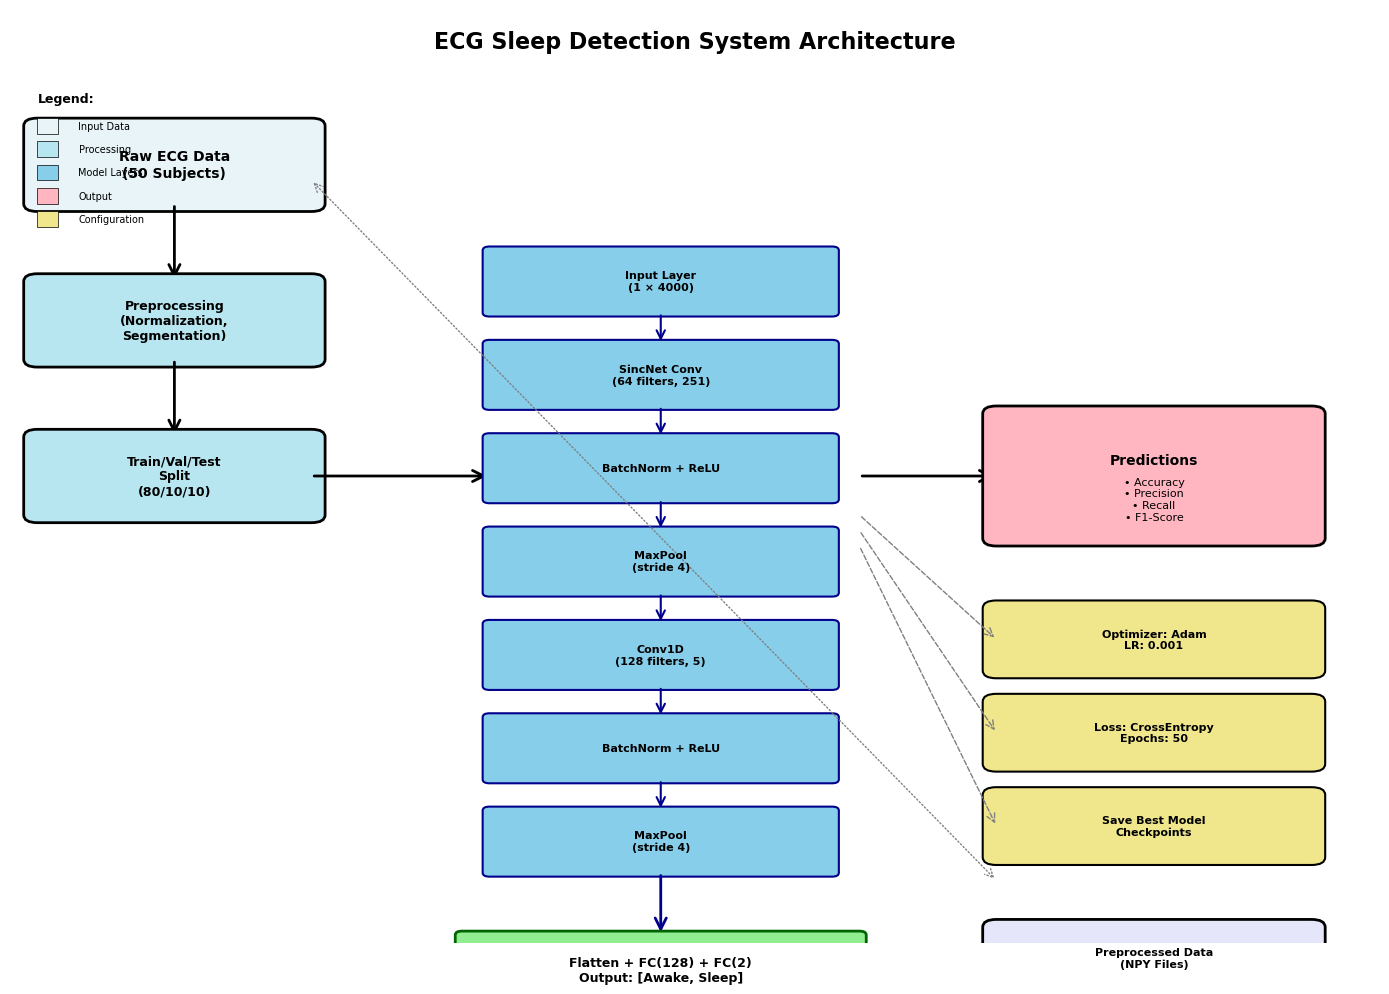

System Architecture diagram saved as 'system_architecture.png'


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# Create system architecture diagram
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(5, 11.5, 'ECG Sleep Detection System Architecture', 
        fontsize=16, fontweight='bold', ha='center')

# Define colors
color_input = '#E8F4F8'
color_process = '#B8E6F0'
color_model = '#87CEEB'
color_output = '#FFB6C1'
color_storage = '#F0E68C'

# ============ INPUT LAYER ============
# Raw ECG Data
input_box = FancyBboxPatch((0.2, 9.5), 2, 1, boxstyle="round,pad=0.1", 
                           edgecolor='black', facecolor=color_input, linewidth=2)
ax.add_patch(input_box)
ax.text(1.2, 10, 'Raw ECG Data\n(50 Subjects)', ha='center', va='center', fontsize=10, fontweight='bold')

# ============ PREPROCESSING ============
# Preprocessing arrow
arrow1 = FancyArrowPatch((1.2, 9.5), (1.2, 8.5), arrowstyle='->', 
                        mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow1)

# Preprocessing box
preprocess_box = FancyBboxPatch((0.2, 7.5), 2, 1, boxstyle="round,pad=0.1",
                               edgecolor='black', facecolor=color_process, linewidth=2)
ax.add_patch(preprocess_box)
ax.text(1.2, 8, 'Preprocessing\n(Normalization,\nSegmentation)', ha='center', va='center', fontsize=9, fontweight='bold')

# ============ DATA PREPARATION ============
# Data prep arrow
arrow2 = FancyArrowPatch((1.2, 7.5), (1.2, 6.5), arrowstyle='->', 
                        mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow2)

# Data split box
data_box = FancyBboxPatch((0.2, 5.5), 2, 1, boxstyle="round,pad=0.1",
                         edgecolor='black', facecolor=color_process, linewidth=2)
ax.add_patch(data_box)
ax.text(1.2, 6, 'Train/Val/Test\nSplit\n(80/10/10)', ha='center', va='center', fontsize=9, fontweight='bold')

# ============ MODEL ARCHITECTURE ============
# Model arrow
arrow3 = FancyArrowPatch((2.2, 6), (3.5, 6), arrowstyle='->', 
                        mutation_scale=20, linewidth=2, color='black')
ax.add_patch(arrow3)

# Model layers - vertical stack
layers = [
    ('Input Layer\n(1 × 4000)', 8.5),
    ('SincNet Conv\n(64 filters, 251)', 7.3),
    ('BatchNorm + ReLU', 6.1),
    ('MaxPool\n(stride 4)', 4.9),
    ('Conv1D\n(128 filters, 5)', 3.7),
    ('BatchNorm + ReLU', 2.5),
    ('MaxPool\n(stride 4)', 1.3),
]

# Draw model architecture boxes
for i, (layer_name, y_pos) in enumerate(layers):
    layer_box = FancyBboxPatch((3.5, y_pos-0.4), 2.5, 0.8, boxstyle="round,pad=0.05",
                              edgecolor='darkblue', facecolor=color_model, linewidth=1.5)
    ax.add_patch(layer_box)
    ax.text(4.75, y_pos, layer_name, ha='center', va='center', fontsize=8, fontweight='bold')
    
    if i < len(layers) - 1:
        arrow = FancyArrowPatch((4.75, y_pos-0.4), (4.75, layers[i+1][1]+0.4), 
                               arrowstyle='->', mutation_scale=15, linewidth=1.5, color='darkblue')
        ax.add_patch(arrow)

# ============ CLASSIFICATION LAYER ============
# Classification arrow
classify_arrow = FancyArrowPatch((4.75, 0.9), (4.75, 0.1), arrowstyle='->', 
                                mutation_scale=20, linewidth=2, color='darkblue')
ax.add_patch(classify_arrow)

classify_box = FancyBboxPatch((3.3, -0.8), 2.9, 0.9, boxstyle="round,pad=0.05",
                             edgecolor='darkgreen', facecolor='#90EE90', linewidth=2)
ax.add_patch(classify_box)
ax.text(4.75, -0.35, 'Flatten + FC(128) + FC(2)\nOutput: [Awake, Sleep]', 
        ha='center', va='center', fontsize=9, fontweight='bold')

# ============ OUTPUT & EVALUATION ============
# Output arrow
output_arrow = FancyArrowPatch((6.2, 6), (7.2, 6), arrowstyle='->', 
                              mutation_scale=20, linewidth=2, color='black')
ax.add_patch(output_arrow)

# Output box
output_box = FancyBboxPatch((7.2, 5.2), 2.3, 1.6, boxstyle="round,pad=0.1",
                           edgecolor='black', facecolor=color_output, linewidth=2)
ax.add_patch(output_box)
ax.text(8.35, 6.2, 'Predictions', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(8.35, 5.7, '• Accuracy\n• Precision\n• Recall\n• F1-Score', 
        ha='center', va='center', fontsize=8)

# ============ TRAINING COMPONENTS ============
# Optimizer
optim_box = FancyBboxPatch((7.2, 3.5), 2.3, 0.8, boxstyle="round,pad=0.1",
                          edgecolor='black', facecolor=color_storage, linewidth=1.5)
ax.add_patch(optim_box)
ax.text(8.35, 3.9, 'Optimizer: Adam\nLR: 0.001', ha='center', va='center', fontsize=8, fontweight='bold')

# Loss function
loss_box = FancyBboxPatch((7.2, 2.3), 2.3, 0.8, boxstyle="round,pad=0.1",
                         edgecolor='black', facecolor=color_storage, linewidth=1.5)
ax.add_patch(loss_box)
ax.text(8.35, 2.7, 'Loss: CrossEntropy\nEpochs: 50', ha='center', va='center', fontsize=8, fontweight='bold')

# Checkpoints
checkpoint_box = FancyBboxPatch((7.2, 1.1), 2.3, 0.8, boxstyle="round,pad=0.1",
                               edgecolor='black', facecolor=color_storage, linewidth=1.5)
ax.add_patch(checkpoint_box)
ax.text(8.35, 1.5, 'Save Best Model\nCheckpoints', ha='center', va='center', fontsize=8, fontweight='bold')

# ============ CONNECTIONS ============
# Training pipeline connections
train_arrow1 = FancyArrowPatch((6.2, 5.5), (7.2, 3.9), arrowstyle='->', 
                              mutation_scale=15, linewidth=1, color='gray', linestyle='dashed')
ax.add_patch(train_arrow1)

train_arrow2 = FancyArrowPatch((6.2, 5.3), (7.2, 2.7), arrowstyle='->', 
                              mutation_scale=15, linewidth=1, color='gray', linestyle='dashed')
ax.add_patch(train_arrow2)

train_arrow3 = FancyArrowPatch((6.2, 5.1), (7.2, 1.5), arrowstyle='->', 
                              mutation_scale=15, linewidth=1, color='gray', linestyle='dashed')
ax.add_patch(train_arrow3)

# ============ DATA STORAGE ============
storage_box = FancyBboxPatch((7.2, -0.8), 2.3, 1, boxstyle="round,pad=0.1",
                            edgecolor='black', facecolor='#E6E6FA', linewidth=2)
ax.add_patch(storage_box)
ax.text(8.35, -0.2, 'Preprocessed Data\n(NPY Files)', ha='center', va='center', fontsize=8, fontweight='bold')

# Arrow from data to preprocessing
data_storage_arrow = FancyArrowPatch((2.2, 9.8), (7.2, 0.8), arrowstyle='<->', 
                                    mutation_scale=15, linewidth=1, color='gray', linestyle='dotted')
ax.add_patch(data_storage_arrow)

# ============ LEGEND ============
legend_y = 10.8
ax.text(0.2, legend_y, 'Legend:', fontsize=9, fontweight='bold')

legend_items = [
    (color_input, 'Input Data'),
    (color_process, 'Processing'),
    (color_model, 'Model Layers'),
    (color_output, 'Output'),
    (color_storage, 'Configuration'),
]

for i, (color, label) in enumerate(legend_items):
    rect = mpatches.Rectangle((0.2, legend_y - 0.4 - i*0.3), 0.15, 0.2, 
                             facecolor=color, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)
    ax.text(0.5, legend_y - 0.3 - i*0.3, label, fontsize=7, va='center')

plt.tight_layout()
plt.savefig('system_architecture.png', dpi=300, bbox_inches='tight')
plt.show()

print("System Architecture diagram saved as 'system_architecture.png'")

# 1D CNN with SincNet for ECG Classification

Notebook ini berisi implementasi lengkap 1D CNN menggunakan SincNet layer untuk klasifikasi data ECG.

## Pipeline:
1. **Import Libraries & Setup**
2. **Model Architecture (SincNet)**
3. **Data Preparation**
4. **Training**
5. **Evaluation & Metrics**
6. **Visualization**

## 1. Import Libraries & Setup

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import math
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

Using device: mps


## 2. Model Architecture - SincNet

In [21]:
class SincConv1d(nn.Module):
    """
    SincNet Convolutional Layer
    Learns bandpass filters directly in the frequency domain
    """
    def __init__(self, out_channels, kernel_size, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        
        # Frequency range
        self.min_freq = 0.5
        self.max_freq = sample_rate / 2 - 1
        
        # Initialize learnable frequency parameters
        low_hz = np.linspace(self.min_freq, 30, out_channels)
        high_hz = low_hz + 5
        
        self.low_hz_ = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))
        
        # Time axis for filter
        n = torch.arange(-(kernel_size // 2), (kernel_size // 2) + 1)
        self.register_buffer("n", n)
    
    def forward(self, x):
        # Clamp frequencies to valid range
        low = self.min_freq + torch.abs(self.low_hz_)
        high = torch.clamp(low + torch.abs(self.band_hz_), 
                          self.min_freq, self.max_freq)
        band = (high - low)[:, None]
        
        # Create bandpass filters using sinc function
        f_t_low = 2 * math.pi * low[:, None] * self.n / self.sample_rate
        f_t_high = 2 * math.pi * high[:, None] * self.n / self.sample_rate
        
        filters = (torch.sin(f_t_high) - torch.sin(f_t_low)) / (self.n / self.sample_rate + 1e-8)
        filters = filters / (2 * band)
        
        # Apply Hamming window
        filters = filters * torch.hamming_window(self.kernel_size + 1).to(x.device)
        filters = filters.unsqueeze(1)
        
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)


class SincNetECG(nn.Module):
    """
    1D CNN with SincNet for ECG Classification
    """
    def __init__(self, sample_rate=200, num_classes=2):
        super().__init__()
        
        # SincNet layer - 8 learnable bandpass filters
        self.sinc = SincConv1d(out_channels=8, kernel_size=252, sample_rate=sample_rate)
        
        # Pooling
        self.pool1 = nn.MaxPool1d(4)
        
        # Additional convolutional layers
        self.conv2 = nn.Conv1d(8, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(4)
        
        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(4)
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(32, num_classes)
    
    def forward(self, x):
        # SincNet layer
        x = torch.relu(self.sinc(x))
        x = self.pool1(x)
        
        # Conv block 2
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        # Conv block 3
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        # Global pooling and classification
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Recreate model instance (clean retrain)
model = SincNetECG(sample_rate=200, num_classes=2).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SincNetECG(
  (sinc): SincConv1d()
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(8, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 13,970


### Capture Initial SincNet Frequencies (Before Training)

In [22]:
# Store initial frequency bands before training (for this retrain)
sinc_layer_init = model.sinc

low_hz_init = sinc_layer_init.min_freq + torch.abs(sinc_layer_init.low_hz_).detach().cpu().numpy()
high_hz_init = low_hz_init + torch.abs(sinc_layer_init.band_hz_).detach().cpu().numpy()
high_hz_init = np.clip(high_hz_init, sinc_layer_init.min_freq, sinc_layer_init.max_freq)

print("Initial SincNet Frequency Bands (Before Training):")
print("=" * 70)
print(f"{'Filter':<10} {'Low (Hz)':<12} {'High (Hz)':<12} {'Bandwidth (Hz)':<15}")
print("-" * 70)
for i in range(len(low_hz_init)):
    bandwidth_init = high_hz_init[i] - low_hz_init[i]
    print(f"Filter {i:<3} {low_hz_init[i]:>10.2f}   {high_hz_init[i]:>10.2f}   {bandwidth_init:>13.2f}")
print("=" * 70)

Initial SincNet Frequency Bands (Before Training):
Filter     Low (Hz)     High (Hz)    Bandwidth (Hz) 
----------------------------------------------------------------------
Filter 0         1.00         6.00            5.00
Filter 1         5.21        10.21            5.00
Filter 2         9.43        14.43            5.00
Filter 3        13.64        18.64            5.00
Filter 4        17.86        22.86            5.00
Filter 5        22.07        27.07            5.00
Filter 6        26.29        31.29            5.00
Filter 7        30.50        35.50            5.00


## 3. Data Preparation

In [23]:
class ECGDataset(Dataset):
    """
    Custom Dataset for ECG data
    """
    def __init__(self, data_dir='segmented_npy'):
        self.data_dir = data_dir
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        
        print(f"Found {len(self.file_list)} files in {data_dir}")
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        filename = self.file_list[idx]
        filepath = os.path.join(self.data_dir, filename)
        
        # Load data
        data = np.load(filepath)
        
        # Extract label from filename (e.g., s1_0001_label0.npy -> label 0)
        label = int(filename.split('_label')[-1].split('.')[0])
        
        # Extract subject ID from filename (e.g., s1_0001_label0.npy -> 1)
        subject_id = int(filename.split('_')[0].replace('s', ''))
        
        # Convert to tensor and add channel dimension
        data = torch.FloatTensor(data).unsqueeze(0)  # Shape: (1, length)
        label = torch.LongTensor([label])[0]
        
        return data, label, subject_id

# Create dataset
dataset = ECGDataset('segmented_npy')
print(f"Dataset size: {len(dataset)}")

# Check data shape
sample_data, sample_label, sample_subject = dataset[0]
print(f"Sample data shape: {sample_data.shape}")
print(f"Sample label: {sample_label}")
print(f"Sample subject ID: {sample_subject}")

# Count labels and subjects
labels = []
subjects = []
for i in range(len(dataset)):
    _, label, subject_id = dataset[i]
    labels.append(label.item())
    subjects.append(subject_id)

unique_labels, counts_labels = np.unique(labels, return_counts=True)
print(f"\nLabel distribution:")
for u, c in zip(unique_labels, counts_labels):
    print(f"  Label {u}: {c} samples ({c/len(labels)*100:.1f}%)")

unique_subjects = np.unique(subjects)
print(f"\nTotal unique subjects: {len(unique_subjects)}")
print(f"Subject IDs: {sorted(unique_subjects)}")

Found 80493 files in segmented_npy
Dataset size: 80493
Sample data shape: torch.Size([1, 27000])
Sample label: 0
Sample subject ID: 2

Label distribution:
  Label 0: 45062 samples (56.0%)
  Label 1: 35431 samples (44.0%)

Total unique subjects: 50
Subject IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]

Label distribution:
  Label 0: 45062 samples (

In [24]:
# Split dataset by subjects to ensure no data leakage
# Group samples by subject
subject_to_indices = {}
for i in range(len(dataset)):
    _, _, subject_id = dataset[i]
    if subject_id not in subject_to_indices:
        subject_to_indices[subject_id] = []
    subject_to_indices[subject_id].append(i)

# Get all unique subjects
all_subjects = sorted(list(subject_to_indices.keys()))
print(f"Total subjects: {len(all_subjects)}")

# Split subjects into train/val/test (70%/15%/15% approximately)
np.random.seed(42)
shuffled_subjects = np.random.permutation(all_subjects)

n_subjects = len(shuffled_subjects)
n_train = int(0.7 * n_subjects)
n_val = int(0.15 * n_subjects)

train_subjects = shuffled_subjects[:n_train]
val_subjects = shuffled_subjects[n_train:n_train+n_val]
test_subjects = shuffled_subjects[n_train+n_val:]

print(f"\nSubject split:")
print(f"  Training subjects ({len(train_subjects)}): {sorted(train_subjects.tolist())}")
print(f"  Validation subjects ({len(val_subjects)}): {sorted(val_subjects.tolist())}")
print(f"  Test subjects ({len(test_subjects)}): {sorted(test_subjects.tolist())}")

# Get indices for each split
train_idx = []
val_idx = []
test_idx = []

for subject in train_subjects:
    train_idx.extend(subject_to_indices[subject])
for subject in val_subjects:
    val_idx.extend(subject_to_indices[subject])
for subject in test_subjects:
    test_idx.extend(subject_to_indices[subject])

print(f"\nSample distribution:")
print(f"  Training set size: {len(train_idx)} samples")
print(f"  Validation set size: {len(val_idx)} samples")
print(f"  Test set size: {len(test_idx)} samples")

# Count labels in each split
train_labels = [labels[i] for i in train_idx]
val_labels = [labels[i] for i in val_idx]
test_labels = [labels[i] for i in test_idx]

print(f"\nLabel distribution per split:")
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    unique, counts = np.unique(split_labels, return_counts=True)
    print(f"  {split_name}:", end=' ')
    for u, c in zip(unique, counts):
        print(f"Label {u}: {c} ({c/len(split_labels)*100:.1f}%)", end=' | ')
    print()

# ---- Balanced sampling (train only) ----
# This helps when the model collapses to predicting one class.
train_labels_np = np.array(train_labels)
class_sample_count = np.bincount(train_labels_np, minlength=2).astype(np.float64)
class_sample_count = np.maximum(class_sample_count, 1.0)
weight_per_class = 1.0 / class_sample_count
samples_weight = weight_per_class[train_labels_np]
samples_weight = torch.from_numpy(samples_weight).double()

balanced_train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=samples_weight, num_samples=len(samples_weight), replacement=True
 )

# Create data loaders
batch_size = 32

# Train: use balanced sampler (do NOT use SubsetRandomSampler at the same time)
train_loader = DataLoader(dataset, batch_size=batch_size, sampler=balanced_train_sampler)

# Val/Test: keep standard subset samplers
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)
val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"\nNumber of batches:")
print(f"  Train: {len(train_loader)}")
print(f"  Validation: {len(val_loader)}")
print(f"  Test: {len(test_loader)}")

Total subjects: 50

Subject split:
  Training subjects (35): [1, 2, 4, 5, 6, 7, 9, 10, 12, 13, 14, 16, 17, 18, 20, 22, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 37, 38, 40, 42, 45, 46, 47, 48, 49]
  Validation subjects (7): [3, 11, 23, 24, 36, 41, 44]
  Test subjects (8): [8, 15, 19, 21, 29, 39, 43, 50]

Sample distribution:
  Training set size: 56908 samples
  Validation set size: 11015 samples
  Test set size: 12570 samples

Label distribution per split:
  Train: Label 0: 33196 (58.3%) | Label 1: 23712 (41.7%) | 
  Val: Label 0: 5397 (49.0%) | Label 1: 5618 (51.0%) | 
  Test: Label 0: 6469 (51.5%) | Label 1: 6101 (48.5%) | 

Number of batches:
  Train: 1779
  Validation: 345
  Test: 393


## 3a. Normal vs Apnea Signal Comparison (Raw `.npy`)

Showing test split examples
  Normal (0): 3 samples
    idx=40069 file=s43_1549_label0.npy
    idx=40132 file=s19_1566_label0.npy
    idx=25182 file=s15_0885_label0.npy
  Apnea (1): 3 samples
    idx=19231 file=s50_1340_label1.npy
    idx=8075 file=s29_0361_label1.npy
    idx=70793 file=s29_0170_label1.npy


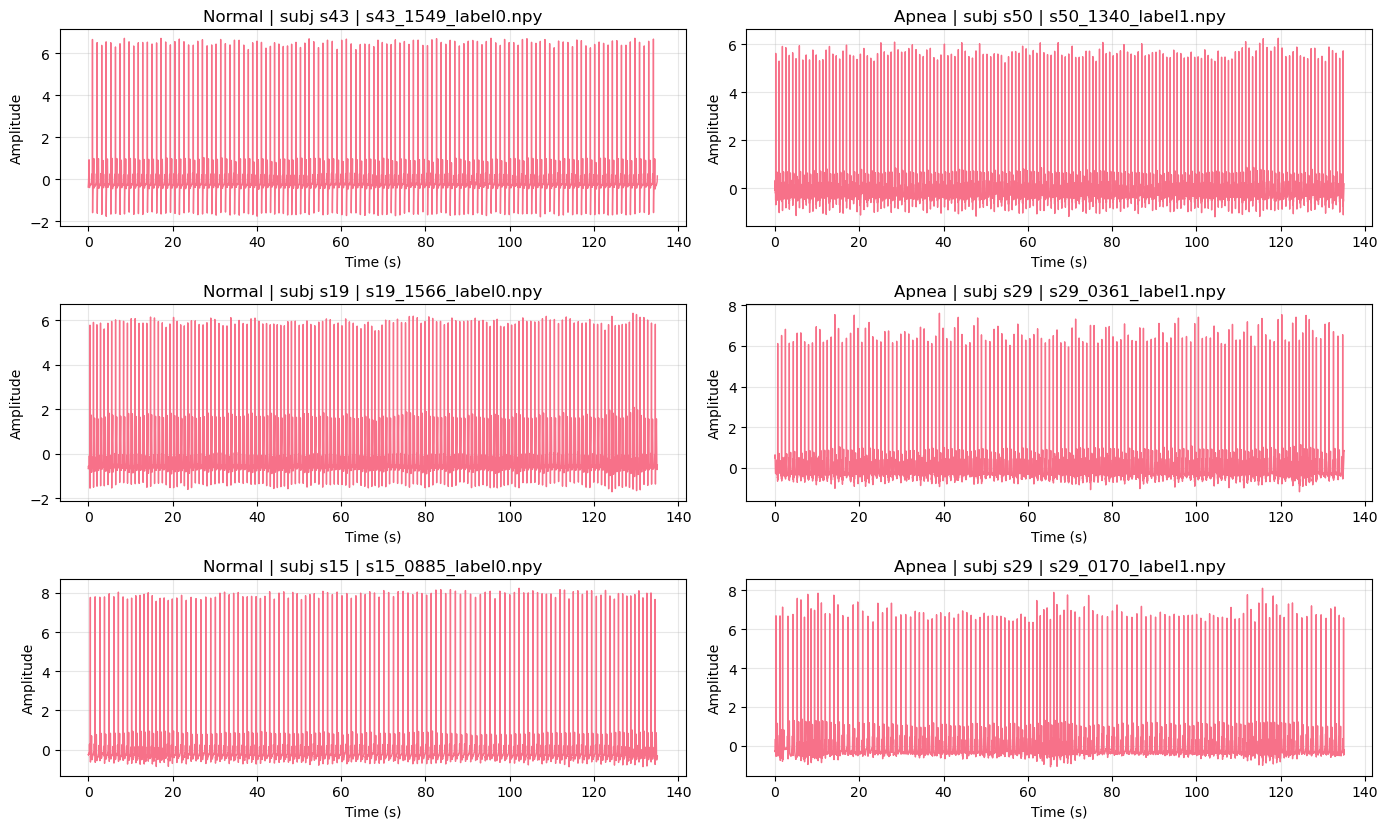

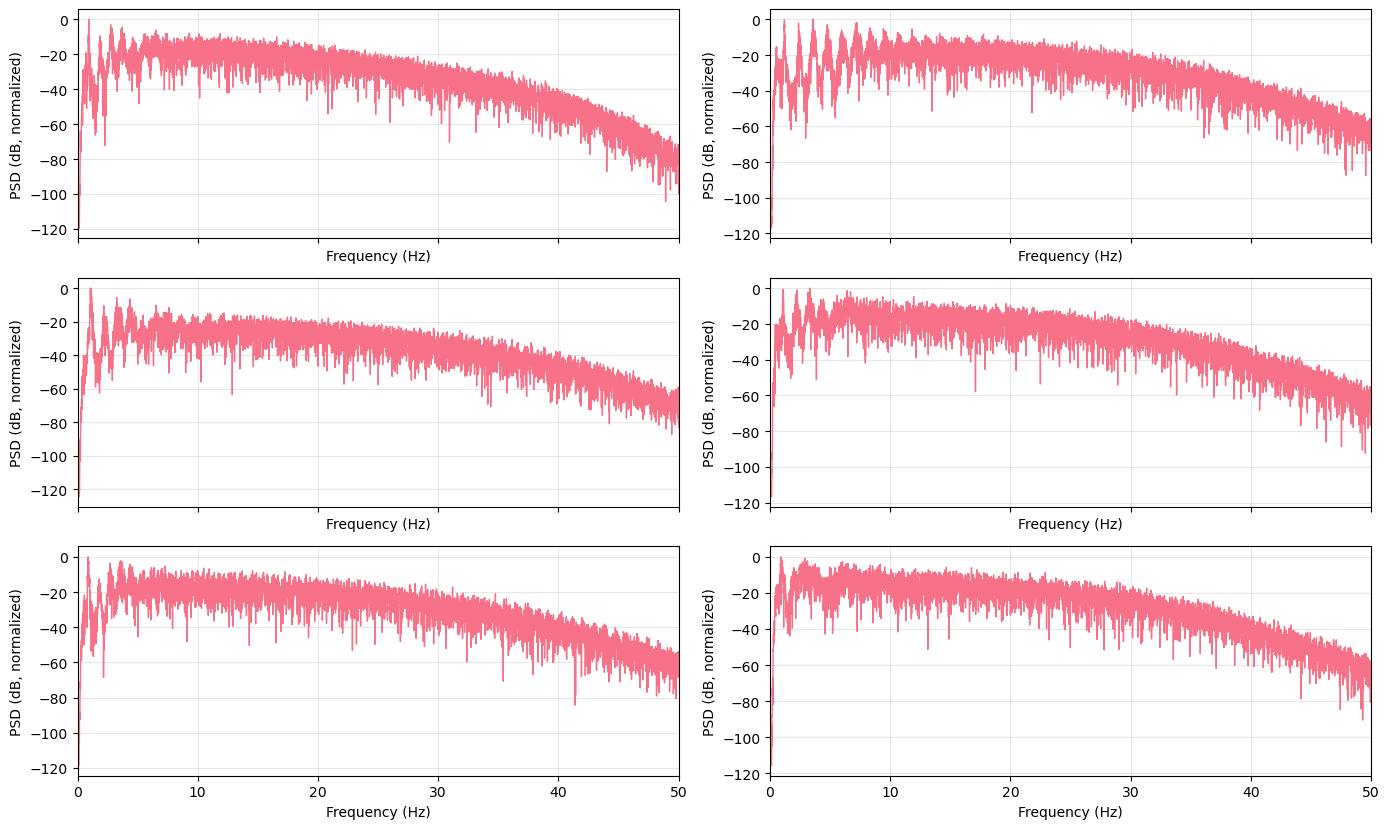

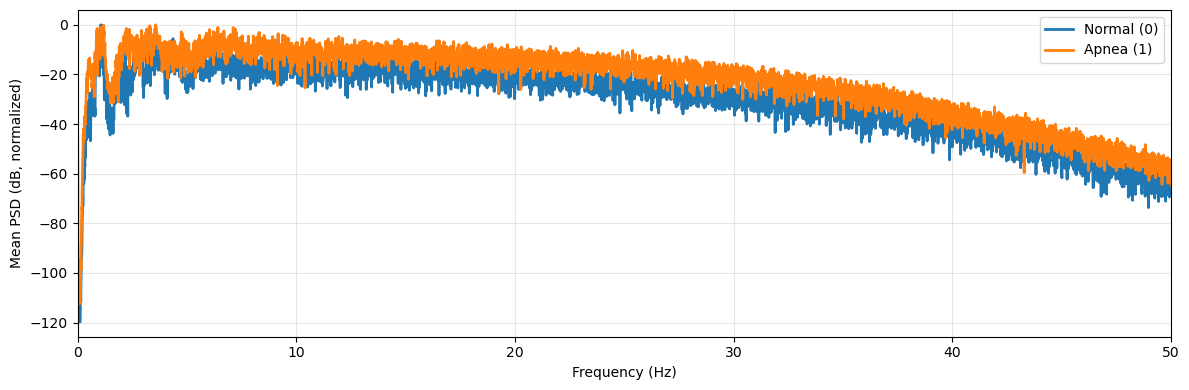

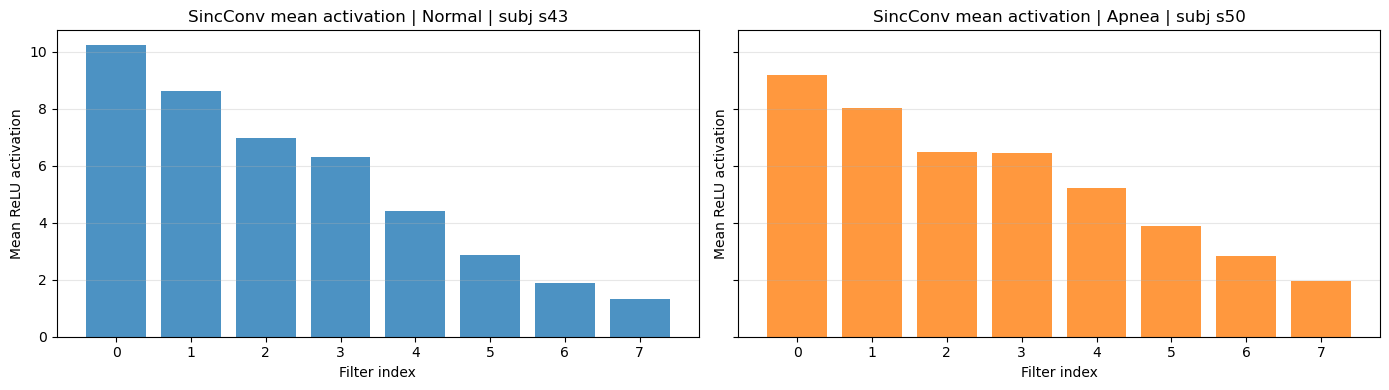

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which split to visualize (recommended: 'test' for generalization)
_split = 'test'  # 'train' | 'val' | 'test'
_per_class = 3   # number of example segments per class
_fs = 200        # sampling rate (Hz)
_rng = np.random.default_rng(42)

if _split == 'train':
    _pool_idx = np.array(train_idx, dtype=int)
elif _split == 'val':
    _pool_idx = np.array(val_idx, dtype=int)
elif _split == 'test':
    _pool_idx = np.array(test_idx, dtype=int)
else:
    raise ValueError("_split must be one of: 'train', 'val', 'test'")

# Indices by label
_pool_labels = np.array([labels[i] for i in _pool_idx], dtype=int)
idx_by_label = {
    0: _pool_idx[_pool_labels == 0],
    1: _pool_idx[_pool_labels == 1],
}

for lab in [0, 1]:
    if len(idx_by_label[lab]) == 0:
        raise RuntimeError(f"No samples for label {lab} in {_split} split")

sel = {}
for lab in [0, 1]:
    take = min(_per_class, len(idx_by_label[lab]))
    sel[lab] = _rng.choice(idx_by_label[lab], size=take, replace=False)

print(f"Showing {_split} split examples")
for lab in [0, 1]:
    name = 'Normal (0)' if lab == 0 else 'Apnea (1)'
    print(f"  {name}: {len(sel[lab])} samples")
    for i in sel[lab]:
        print(f"    idx={int(i)} file={dataset.file_list[int(i)]}")


def _psd_rfft(x: np.ndarray, fs: float):
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean()
    n = x.size
    win = np.hanning(n)
    xw = x * win
    X = np.fft.rfft(xw)
    psd = (np.abs(X) ** 2) / (fs * (win**2).sum())
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    return freqs, psd


def _load_1d(idx: int):
    x_t, y_t, subj = dataset[int(idx)]
    x = x_t.squeeze(0).detach().cpu().numpy()
    y = int(y_t.item())
    return x, y, int(subj)


# Plot time-domain signals (examples)
max_rows = max(len(sel[0]), len(sel[1]))
fig, axes = plt.subplots(max_rows, 2, figsize=(14, 2.8 * max_rows), sharex=False)
if max_rows == 1:
    axes = np.array([axes])

for r in range(max_rows):
    for c, lab in enumerate([0, 1]):
        ax = axes[r, c]
        if r >= len(sel[lab]):
            ax.axis('off')
            continue
        idx = int(sel[lab][r])
        x, y, subj = _load_1d(idx)
        t = np.arange(x.size) / _fs
        ax.plot(t, x, lw=1.0)
        title = f"{'Normal' if y==0 else 'Apnea'} | subj s{subj} | {dataset.file_list[idx]}"
        ax.set_title(title)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Plot PSD (examples) and store for class-average
fig, axes = plt.subplots(max_rows, 2, figsize=(14, 2.8 * max_rows), sharex=True, sharey=False)
if max_rows == 1:
    axes = np.array([axes])

avg_psd = {0: [], 1: []}
avg_f = {0: [], 1: []}

for r in range(max_rows):
    for c, lab in enumerate([0, 1]):
        ax = axes[r, c]
        if r >= len(sel[lab]):
            ax.axis('off')
            continue
        idx = int(sel[lab][r])
        x, y, subj = _load_1d(idx)
        f, p = _psd_rfft(x, _fs)
        avg_psd[lab].append(p)
        avg_f[lab].append(f)

        # plot in dB, normalized to its max for shape comparison
        p_db = 10 * np.log10(np.maximum(p, 1e-12))
        p_db = p_db - p_db.max()
        ax.plot(f, p_db, lw=1.0)
        ax.set_xlim(0, min(50, f.max()))
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (dB, normalized)')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Average PSD per class (over selected examples)
fig, ax = plt.subplots(figsize=(12, 4))
for lab, color in [(0, 'tab:blue'), (1, 'tab:orange')]:
    if len(avg_psd[lab]) == 0:
        continue

    # If segment lengths differ, truncate to the minimum rFFT length
    min_len = min(p.size for p in avg_psd[lab])
    P = np.stack([p[:min_len] for p in avg_psd[lab]], axis=0)

    # Use matching frequency axis (truncate too)
    f0 = avg_f[lab][0][:min_len]

    Pm = P.mean(axis=0)
    pm_db = 10 * np.log10(np.maximum(Pm, 1e-12))
    pm_db = pm_db - pm_db.max()

    ax.plot(f0, pm_db, lw=2.0, color=color, label=('Normal (0)' if lab==0 else 'Apnea (1)'))

ax.set_xlim(0, 50)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Mean PSD (dB, normalized)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# Optional: compare SincConv activations (if model exists)
try:
    import torch
    import torch.nn.functional as F

    model.eval()
    with torch.no_grad():
        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
        for ax, lab, color in [(axes[0], 0, 'tab:blue'), (axes[1], 1, 'tab:orange')]:
            idx = int(sel[lab][0])
            x, y, subj = _load_1d(idx)
            x_t = torch.from_numpy(x).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,L)
            a = F.relu(model.sinc(x_t))  # (1, F, L)

            # summarize per-filter energy
            per_filter = a.squeeze(0).mean(dim=-1).detach().cpu().numpy()
            ax.bar(np.arange(per_filter.size), per_filter, color=color, alpha=0.8)
            ax.set_title(f"SincConv mean activation | {'Normal' if lab==0 else 'Apnea'} | subj s{subj}")
            ax.set_xlabel('Filter index')
            ax.set_ylabel('Mean ReLU activation')
            ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("(Skipping SincConv activation plot)")
    print("Reason:", repr(e))


## 4. Training Setup

In [25]:
# Training configuration
num_epochs = 50
learning_rate = 0.001

# ---- Class balancing (important with subject-level split) ----
# Compute class weights from TRAIN split only
train_counts = np.bincount(np.array(train_labels), minlength=2).astype(np.float64)
train_total = train_counts.sum()
class_weights = train_total / (2.0 * np.maximum(train_counts, 1.0))  # inverse frequency
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

print("Train label counts:", train_counts.astype(int).tolist())
print("Class weights:", class_weights.tolist())

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Create checkpoint directory
os.makedirs('checkpoint_epoch', exist_ok=True)

print("Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: Adam")
print(f"  Loss function: CrossEntropyLoss (weighted)")
print(f"  Scheduler: ReduceLROnPlateau")

Train label counts: [33196, 23712]
Class weights: [0.8571514640318111, 1.1999831309041835]
Training configuration:
  Epochs: 50
  Learning rate: 0.001
  Optimizer: Adam
  Loss function: CrossEntropyLoss (weighted)
  Scheduler: ReduceLROnPlateau
Training configuration:
  Epochs: 50
  Learning rate: 0.001
  Optimizer: Adam
  Loss function: CrossEntropyLoss (weighted)
  Scheduler: ReduceLROnPlateau


In [41]:
# ========== DIAGNOSTICS CONFIG ==========
TARGET_LAYER_NAME = "sinc"  # or "conv2", "conv3"
DIAG_EVERY = 1              # log diagnostics every N epochs
ACT_EVERY = 5               # visualize activations every N epochs
EPS_DEAD_MEAN = 1e-6        # threshold for dead filter detection (mean)
EPS_DEAD_STD = 1e-6         # threshold for dead filter detection (std)
RUN_GRADCHECK = False       # enable torch.autograd.gradcheck for custom layers
RUN_OVERFIT_TEST = False    # enable single-batch overfitting test

def get_layer(model, name):
    """Retrieve a named layer; error nicely if not found."""
    try:
        return getattr(model, name)
    except AttributeError:
        available = [k for k, _ in model.named_modules() if not k.startswith('_')]
        print(f"Layer '{name}' not found. Available: {available}")
        raise

# Test layer access
target_layer = get_layer(model, TARGET_LAYER_NAME)
print(f"Target layer for diagnostics: {TARGET_LAYER_NAME}")
print(f"  Type: {type(target_layer).__name__}")
print(f"Diagnostics config: DIAG_EVERY={DIAG_EVERY}, ACT_EVERY={ACT_EVERY}")


Target layer for diagnostics: sinc
  Type: SincConv1d
Diagnostics config: DIAG_EVERY=1, ACT_EVERY=5


In [42]:
import torch.autograd

# ========== TENSOR STATS ==========
def tensor_stats(t):
    """Compute statistics on a tensor. Handle None/NaN/Inf gracefully."""
    if t is None:
        return {'status': 'None'}
    t_cpu = t.detach().cpu().float()
    if t_cpu.numel() == 0:
        return {'status': 'empty'}
    t_flat = t_cpu.view(-1)
    has_nan = torch.isnan(t_flat).any().item()
    has_inf = torch.isinf(t_flat).any().item()
    if has_nan or has_inf:
        return {'status': 'NaN/Inf', 'has_nan': bool(has_nan), 'has_inf': bool(has_inf)}
    return {
        'mean': float(t_flat.mean()),
        'std': float(t_flat.std()),
        'min': float(t_flat.min()),
        'max': float(t_flat.max()),
        'l2_norm': float(torch.norm(t_flat, p=2)),
        'abs_mean': float(torch.abs(t_flat).mean()),
    }


# ========== WEIGHT SNAPSHOT ==========
def snapshot_weights(layer):
    """Clone weight/bias parameters from a layer."""
    snapshot = {}
    for name, param in layer.named_parameters():
        if param.requires_grad:
            snapshot[name] = param.data.clone().detach()
    return snapshot


# ========== UPDATE RATIO ==========
def compute_update_ratio(prev_snapshot, layer):
    """Compute weight update magnitude as % of current weight."""
    ratios = {}
    for name, param in layer.named_parameters():
        if name in prev_snapshot and param.requires_grad:
            prev = prev_snapshot[name]
            curr = param.data
            delta = (curr - prev).norm().item()
            curr_norm = curr.norm().item() + 1e-12
            ratio = delta / curr_norm
            ratios[name] = ratio
    return ratios if ratios else None


# ========== GRADIENT STATS ==========
def gradient_stats(layer):
    """Collect gradient statistics for layer parameters."""
    stats = {}
    for name, param in layer.named_parameters():
        if param.grad is None:
            stats[name] = {'grad_status': 'None'}
        else:
            stats[name] = tensor_stats(param.grad)
    return stats


# ========== FORWARD HOOK FOR ACTIVATIONS ==========
ACTIVATIONS = {}  # global dict to store hook outputs

def register_activation_hook(layer, name='activation'):
    """Register a forward hook to capture layer outputs."""
    def hook_fn(mod, inp, out):
        ACTIVATIONS[name] = out.detach()
    return layer.register_forward_hook(hook_fn)


# ========== DEAD FILTER DETECTION ==========
def dead_filter_report(activation, eps_mean=1e-6, eps_std=1e-6):
    """
    Detect dead filters in a Conv1d output (B, C, T).
    Returns: (dead_pct, dead_mask, stats_per_channel)
    """
    if activation is None:
        return 0.0, None, None
    
    # activation shape: (B, C, T)
    act = activation.detach().cpu().float()
    if act.dim() != 3:
        return 0.0, None, None
    
    # Stats per channel across batch and time
    B, C, T = act.shape
    per_ch_abs_mean = act.abs().view(B, C, -1).mean(dim=(0, 2))  # (C,)
    per_ch_std = act.view(B, C, -1).std(dim=(0, 2))  # (C,)
    
    # Dead if either mean or std is below threshold
    dead_mask = (per_ch_abs_mean < eps_mean) | (per_ch_std < eps_std)
    dead_pct = float(dead_mask.sum()) / C * 100.0
    
    stats = {
        'per_ch_abs_mean': per_ch_abs_mean.numpy(),
        'per_ch_std': per_ch_std.numpy(),
        'dead_mask': dead_mask.numpy(),
    }
    return dead_pct, dead_mask, stats


print("Diagnostic helpers loaded.")


Diagnostic helpers loaded.


In [43]:
# ========== OVERFIT-ONE-BATCH TEST ==========
def overfit_one_batch(model, train_loader, criterion, device, target_layer_name, 
                     n_steps=300, n_samples=5, print_every=50):
    """
    Try to overfit a single batch. If fails, suggests likely causes.
    """
    print("\n" + "="*70)
    print("OVERFIT-ONE-BATCH TEST")
    print("="*70)
    
    # Get one batch
    for data, labels, _ in train_loader:
        # Reduce to n_samples
        if data.size(0) > n_samples:
            data = data[:n_samples]
            labels = labels[:n_samples]
        break
    
    data, labels = data.to(device), labels.to(device)
    
    # Train on this batch only
    model.train()
    opt_test = optim.Adam(model.parameters(), lr=0.01)  # higher LR for test
    
    losses = []
    accs = []
    
    for step in range(n_steps):
        opt_test.zero_grad()
        out = model(data)
        loss = criterion(out, labels)
        loss.backward()
        opt_test.step()
        
        losses.append(loss.item())
        with torch.no_grad():
            pred = out.argmax(dim=1)
            acc = (pred == labels).float().mean().item()
        accs.append(acc)
        
        if (step + 1) % print_every == 0:
            print(f"Step {step+1:3d}: Loss={loss.item():.6f} | Acc={acc*100:.1f}%")
    
    print(f"\nFinal Loss: {losses[-1]:.6f}")
    print(f"Final Acc:  {accs[-1]*100:.1f}%")
    
    if losses[-1] > 0.1:
        print("\n⚠️  WARNING: Loss did not decrease substantially.")
        print("Likely causes:")
        print("  - Model parameters frozen or requires_grad=False")
        print("  - Labels incorrect or all same class")
        print("  - Gradient flow blocked (custom layer not implemented correctly)")
        print("  - Learning rate too low")
        return False
    elif accs[-1] < 0.95:
        print("\n⚠️  WARNING: Accuracy did not reach 95%+")
        print("Possible causes: as above")
        return False
    else:
        print("\n✅ PASS: Model can overfit a single batch.")
        return True


# ========== GRADCHECK FOR CUSTOM SINC LAYER ==========
def test_gradcheck_sinc(sinc_layer, eps=1e-6, atol=1e-4):
    """
    Run torch.autograd.gradcheck on SincConv1d.
    Must use CPU + double precision.
    """
    print("\n" + "="*70)
    print("GRADIENT CHECK (SincConv1d)")
    print("="*70)
    
    if not isinstance(sinc_layer, SincConv1d):
        print(f"Skipping gradcheck: layer is {type(sinc_layer).__name__}, not SincConv1d")
        return
    
    # Create test input: (1, 1, 256) with double precision on CPU
    x = torch.randn(1, 1, 256, dtype=torch.float64, requires_grad=True)
    
    # Convert layer to double on CPU
    sinc_double = sinc_layer.double().cpu()
    x = x.cpu()
    
    def func(inp):
        return sinc_double(inp)
    
    try:
        result = torch.autograd.gradcheck(func, (x,), eps=eps, atol=atol, raise_exception=True)
        if result:
            print("✅ PASS: Gradient check successful.")
        else:
            print("❌ FAIL: Gradient check failed (numerical mismatch).")
    except Exception as e:
        print(f"❌ FAIL: Gradient check raised exception.")
        print(f"  Error: {e}")
        print("\nAdvice:")
        print("  - Check SincConv1d.forward() for non-differentiable ops")
        print("  - Avoid in-place operations")
        print("  - Ensure all constants are tensors, not numpy/scalars")


print("Overfit and gradcheck utilities loaded.")


Overfit and gradcheck utilities loaded.


## 4b. Diagnostics Helpers

## 4a. Diagnostics Configuration

In [ ]:
# Training function with minimal diagnostics instrumentation
def train_epoch(model, train_loader, criterion, optimizer, device, target_layer=None, collect_diag=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Diagnostics accumulators (first batch only)
    diag_dict = {'grad_l2': None, 'update_ratio': None, 'weight_l2': None}
    
    for batch_idx, (data, labels, _) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Diagnostics: collect on first batch only
        if collect_diag and target_layer is not None and batch_idx == 0:
            try:
                g_stats = gradient_stats(target_layer)
                grad_norms = [v.get('l2_norm', 0) for v in g_stats.values() if isinstance(v, dict) and 'l2_norm' in v]
                diag_dict['grad_l2'] = float(np.mean(grad_norms)) if grad_norms else None
                
                # Snapshot before step
                prev_snap = snapshot_weights(target_layer)
            except:
                prev_snap = None
        
        optimizer.step()
        
        # Diagnostics: update ratio (after step)
        if collect_diag and target_layer is not None and batch_idx == 0 and prev_snap is not None:
            try:
                ratios = compute_update_ratio(prev_snap, target_layer)
                if ratios:
                    ratio_vals = list(ratios.values())
                    diag_dict['update_ratio'] = float(np.mean(ratio_vals))
            except:
                pass
        
        # Weight stats
        if collect_diag and target_layer is not None and batch_idx == 0:
            try:
                w_stats = {name: tensor_stats(param) for name, param in target_layer.named_parameters()}
                w_norms = [v.get('l2_norm', 0) for v in w_stats.values() if isinstance(v, dict) and 'l2_norm' in v]
                diag_dict['weight_l2'] = float(np.mean(w_norms)) if w_norms else None
            except:
                pass
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, diag_dict


# Validation function
def validate(model, val_loader, criterion, device):


Training and validation functions defined.


## 5. Train Model

In [ ]:
# Training loop (with early stopping on VAL macro-F1)
# + Per-epoch SincNet (SincConv) frequency-band logging

def _get_sinc_bands(sinc_layer):
    """Return (low_hz, high_hz, center_hz, bandwidth_hz) as numpy arrays."""
    low = sinc_layer.min_freq + torch.abs(sinc_layer.low_hz_).detach().cpu().numpy()
    high = low + torch.abs(sinc_layer.band_hz_).detach().cpu().numpy()
    high = np.clip(high, sinc_layer.min_freq, sinc_layer.max_freq)
    center = 0.5 * (low + high)
    bandwidth = high - low
    return low.astype(np.float32), high.astype(np.float32), center.astype(np.float32), bandwidth.astype(np.float32)


history = {
    'train_loss': [],
    
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_macro_f1': [],
    # SincNet evolution
    'sinc_epoch': [],
    'sinc_low_hz': [],
    'sinc_high_hz': [],
    'sinc_center_hz': [],
    'sinc_bandwidth_hz': [],
    # Diagnostics
    'diag_weight_l2': [],
    'diag_grad_l2': [],
    'diag_update_ratio': [],
    'diag_dead_pct': [],
}

best_val_acc = 0.0
best_epoch = 0

best_val_macro_f1 = -1.0
best_macro_epoch = 0
early_stop_patience = 8
early_stop_min_delta = 1e-4
no_improve_epochs = 0

# Log initial (epoch 0) SincNet bands before any training updates
low0, high0, center0, bw0 = _get_sinc_bands(model.sinc)
history['sinc_epoch'].append(0)
history['sinc_low_hz'].append(low0)
history['sinc_high_hz'].append(high0)
history['sinc_center_hz'].append(center0)
history['sinc_bandwidth_hz'].append(bw0)

print("Starting training...")
print("=" * 90)
print("Tracking best checkpoint by VAL macro-F1 (more reliable than accuracy here).")
print(f"Logged initial SincNet bands at epoch 0 (n_filters={len(low0)}).")

for epoch in range(num_epochs):
    # Train with diagnostics (collect on first batch)
    collect_diag = ((epoch + 1) % DIAG_EVERY == 0)
    train_loss, train_acc, diag_dict = train_epoch(
        model, train_loader, criterion, optimizer, device,
        target_layer=target_layer if collect_diag else None,
        collect_diag=collect_diag
    )

    # Validate (loss/acc)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Validate (macro-F1)
    yv_true, yv_pred, _ = evaluate_model(model, val_loader, device)
    val_macro_f1 = f1_score(yv_true, yv_pred, average='macro')

    # Log SincNet bands after this epoch update
    low, high, center, bw = _get_sinc_bands(model.sinc)
    history['sinc_epoch'].append(epoch + 1)
    history['sinc_low_hz'].append(low)
    history['sinc_high_hz'].append(high)
    history['sinc_center_hz'].append(center)
    history['sinc_bandwidth_hz'].append(bw)

    # Store history (training)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_macro_f1)
    
    # Store diagnostics
    history['diag_weight_l2'].append(diag_dict.get('weight_l2'))
    history['diag_grad_l2'].append(diag_dict.get('grad_l2'))
    history['diag_update_ratio'].append(diag_dict.get('update_ratio'))
    
    # Log dead filters if we have activations
    dead_pct = 0.0
    if (epoch + 1) % ACT_EVERY == 0:
        try:
            hook = register_activation_hook(target_layer, name='target')
            # Forward pass on first batch
            for data, _, _ in train_loader:
                data = data.to(device)
                with torch.no_grad():
                    _ = model(data)
                break
            hook_out = ACTIVATIONS.get('target')
            if hook_out is not None:
                dead_pct, _, _ = dead_filter_report(hook_out, eps_mean=EPS_DEAD_MEAN, eps_std=EPS_DEAD_STD)
            hook.remove()
        except:
            pass
    
    history['diag_dead_pct'].append(dead_pct)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Print progress
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val Macro-F1: {val_macro_f1:.4f}")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'checkpoint_epoch/checkpoint_epoch{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_macro_f1': val_macro_f1,
        }, checkpoint_path)

    # Save best-by-accuracy (kept for reference)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_macro_f1': val_macro_f1,
        }, 'checkpoint_epoch/model_best_acc.pt')

    # Save best-by-macroF1 (primary) + early stopping
    if val_macro_f1 > (best_val_macro_f1 + early_stop_min_delta):
        best_val_macro_f1 = val_macro_f1
        best_macro_epoch = epoch + 1
        no_improve_epochs = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_macro_f1': val_macro_f1,
        }, 'checkpoint_epoch/model_best.pt')
        print(f"  → Best model saved! (Val Macro-F1: {val_macro_f1:.4f})")
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= early_stop_patience:
            print(f"  → Early stopping: no macro-F1 improvement for {early_stop_patience} epochs.")
            break

print("=" * 90)
print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch} (saved to checkpoint_epoch/model_best_acc.pt)")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f} at epoch {best_macro_epoch} (saved to checkpoint_epoch/model_best.pt)")
print("SincNet band evolution logged in history['sinc_*'].")


Starting training...
Tracking best checkpoint by VAL macro-F1 (more reliable than accuracy here).
Logged initial SincNet bands at epoch 0 (n_filters=8).
Epoch [ 1/50] | Train Loss: 0.3740 | Train Acc: 82.15% | Val Loss: 0.2703 | Val Acc: 86.90% | Val Macro-F1: 0.8675
  → Best model saved! (Val Macro-F1: 0.8675)
Epoch [ 1/50] | Train Loss: 0.3740 | Train Acc: 82.15% | Val Loss: 0.2703 | Val Acc: 86.90% | Val Macro-F1: 0.8675
  → Best model saved! (Val Macro-F1: 0.8675)
Epoch [ 2/50] | Train Loss: 0.3756 | Train Acc: 81.87% | Val Loss: 0.2517 | Val Acc: 88.81% | Val Macro-F1: 0.8874
  → Best model saved! (Val Macro-F1: 0.8874)
Epoch [ 2/50] | Train Loss: 0.3756 | Train Acc: 81.87% | Val Loss: 0.2517 | Val Acc: 88.81% | Val Macro-F1: 0.8874
  → Best model saved! (Val Macro-F1: 0.8874)
Epoch [ 3/50] | Train Loss: 0.3768 | Train Acc: 81.85% | Val Loss: 0.2623 | Val Acc: 88.95% | Val Macro-F1: 0.8895
  → Best model saved! (Val Macro-F1: 0.8895)
Epoch [ 3/50] | Train Loss: 0.3768 | Train Acc:

In [ ]:
# Optional pre-training sanity checks

if RUN_GRADCHECK:
    print("Running gradient check on SincConv1d...")
    test_gradcheck_sinc(model.sinc, eps=1e-6, atol=1e-4)

if RUN_OVERFIT_TEST:
    print("\nRunning overfit-one-batch test...")
    success = overfit_one_batch(
        model, train_loader, criterion, device, TARGET_LAYER_NAME,
        n_steps=300, n_samples=5, print_every=50
    )
    if not success:
        print("\n⚠️  Overfit test failed. Check model and data before training.")
    else:
        print("\nProceed with full training.")

print("\nPre-checks complete. Ready to train.")


## 4c. Pre-Training Checks (Optional)

## 5a. SincNet Layer Changes Per Epoch

Logged SincNet bands: epochs=19 (including epoch 0), filters=8
Saved: sincnet_epoch_bands.csv


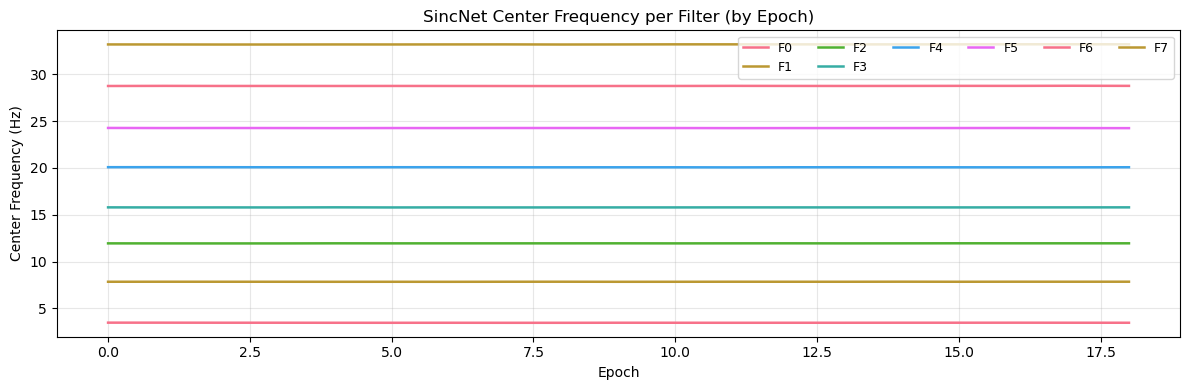

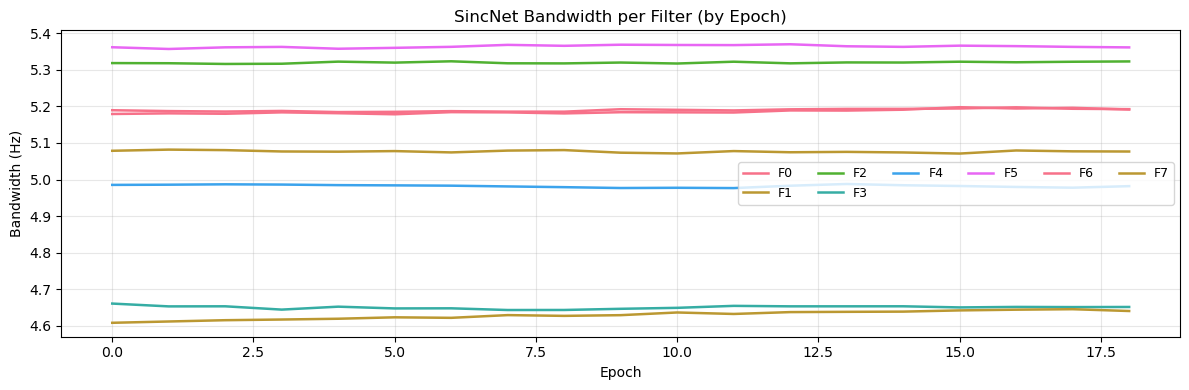

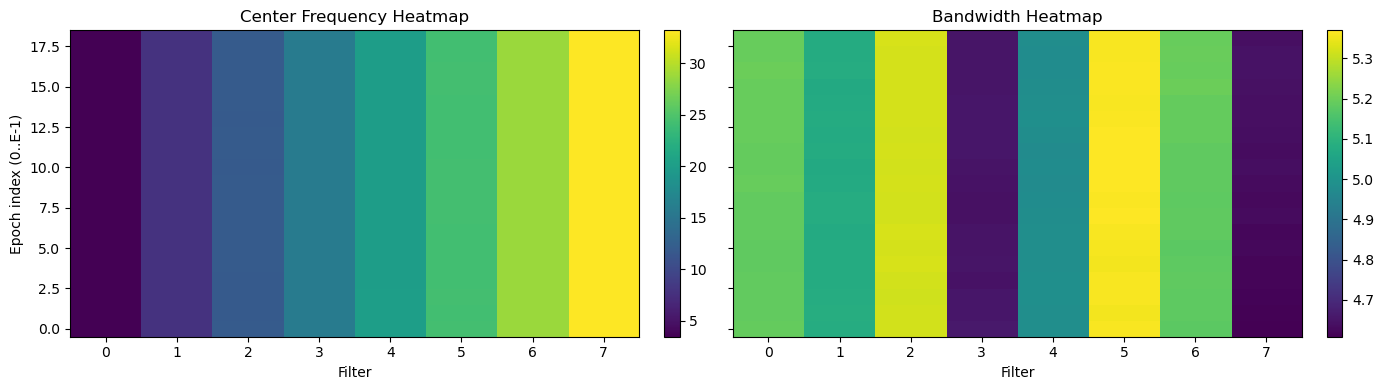

,start_epoch,start_filter,start_low_hz,start_high_hz,start_center_hz,start_bandwidth_hz,end_epoch,end_filter,end_low_hz,end_high_hz,end_center_hz,end_bandwidth_hz,filter,delta_low_hz,delta_high_hz,delta_center_hz,delta_bandwidth_hz
0,0,0,0.892477,6.081917,3.487197,5.189440,18,0,0.879864,6.072251,3.476058,5.192387,0,-0.012613,-0.009666,-0.011139,0.002947
1,0,1,5.311018,10.389623,7.850321,5.078604,18,1,5.317242,10.393840,7.855541,5.076598,1,0.006223,0.004217,0.005220,-0.002006
2,0,2,9.287072,14.605333,11.946203,5.318261,18,2,9.290706,14.613493,11.952099,5.322787,2,0.003633,0.008160,0.005896,0.004526
3,0,3,13.456783,18.117859,15.787321,4.661076,18,3,13.461718,18.113503,15.787610,4.651785,3,0.004934,-0.004356,0.000289,-0.009291
4,0,4,17.581606,22.567001,20.074303,4.985395,18,4,17.576765,22.558704,20.067734,4.981939,4,-0.004841,-0.008297,-0.006569,-0.003456
5,0,5,21.579840,26.941385,24.260612,5.361546,18,5,21.558516,26.919653,24.239084,5.361137,5,-0.021324,-0.021732,-0.021528,-0.000408
6,0,6,26.147295,31.326452,28.736874,5.179157,18,6,26.154116,31.345470,28.749794,5.191355,6,0.006821,0.019018,0.012920,0.012197
7,0,7,30.865646,35.474190,33.169918,4.608543,18,7,30.862577,35.503323,33.182949,4.640745,7,-0.003069,0.029133,0.013031,0.032202


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This section visualizes how the learned SincNet frequency bands change per epoch.
# NOTE: To populate the logs, re-run the training cell (Cell 17).

required = ['sinc_epoch', 'sinc_low_hz', 'sinc_high_hz', 'sinc_center_hz', 'sinc_bandwidth_hz']
missing = [k for k in required if k not in history]

if len(missing) > 0 or len(history.get('sinc_epoch', [])) == 0:
    print("SincNet per-epoch logs not found.")
    print("Run the training cell first so history['sinc_*'] is populated.")
else:
    epochs = np.array(history['sinc_epoch'], dtype=int)
    low = np.stack(history['sinc_low_hz'], axis=0)          # (E, F)
    high = np.stack(history['sinc_high_hz'], axis=0)        # (E, F)
    center = np.stack(history['sinc_center_hz'], axis=0)    # (E, F)
    bw = np.stack(history['sinc_bandwidth_hz'], axis=0)     # (E, F)

    n_epochs, n_filters = center.shape
    print(f"Logged SincNet bands: epochs={n_epochs} (including epoch 0), filters={n_filters}")

    # Long-form table (easy to export / analyze)
    rows = []
    for ei, ep in enumerate(epochs):
        for fi in range(n_filters):
            rows.append({
                'epoch': int(ep),
                'filter': int(fi),
                'low_hz': float(low[ei, fi]),
                'high_hz': float(high[ei, fi]),
                'center_hz': float(center[ei, fi]),
                'bandwidth_hz': float(bw[ei, fi]),
            })

    sinc_epoch_df = pd.DataFrame(rows)
    sinc_epoch_df.to_csv('sincnet_epoch_bands.csv', index=False)
    print("Saved: sincnet_epoch_bands.csv")

    # 1) Line plot: center frequency per filter across epochs
    fig, ax = plt.subplots(figsize=(12, 4))
    for fi in range(n_filters):
        ax.plot(epochs, center[:, fi], lw=1.8, label=f"F{fi}")
    ax.set_title('SincNet Center Frequency per Filter (by Epoch)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Center Frequency (Hz)')
    ax.grid(True, alpha=0.3)
    if n_filters <= 12:
        ax.legend(ncol=min(6, n_filters), fontsize=9)
    plt.tight_layout()
    plt.show()

    # 2) Line plot: bandwidth per filter across epochs
    fig, ax = plt.subplots(figsize=(12, 4))
    for fi in range(n_filters):
        ax.plot(epochs, bw[:, fi], lw=1.8, label=f"F{fi}")
    ax.set_title('SincNet Bandwidth per Filter (by Epoch)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Bandwidth (Hz)')
    ax.grid(True, alpha=0.3)
    if n_filters <= 12:
        ax.legend(ncol=min(6, n_filters), fontsize=9)
    plt.tight_layout()
    plt.show()

    # 3) Heatmaps: center and bandwidth (epochs x filters)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    im0 = axes[0].imshow(center, aspect='auto', origin='lower')
    axes[0].set_title('Center Frequency Heatmap')
    axes[0].set_xlabel('Filter')
    axes[0].set_ylabel('Epoch index (0..E-1)')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(bw, aspect='auto', origin='lower')
    axes[1].set_title('Bandwidth Heatmap')
    axes[1].set_xlabel('Filter')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # 4) Bands at start vs end (easy sanity check)
    df0 = sinc_epoch_df[sinc_epoch_df['epoch'] == int(epochs.min())].sort_values('filter')
    dfl = sinc_epoch_df[sinc_epoch_df['epoch'] == int(epochs.max())].sort_values('filter')

    delta = dfl[['filter', 'low_hz', 'high_hz', 'center_hz', 'bandwidth_hz']].reset_index(drop=True)
    delta[['low_hz', 'high_hz', 'center_hz', 'bandwidth_hz']] = (
        delta[['low_hz', 'high_hz', 'center_hz', 'bandwidth_hz']].values
        - df0[['low_hz', 'high_hz', 'center_hz', 'bandwidth_hz']].values
    )
    delta = delta.rename(columns={
        'low_hz': 'delta_low_hz',
        'high_hz': 'delta_high_hz',
        'center_hz': 'delta_center_hz',
        'bandwidth_hz': 'delta_bandwidth_hz',
    })

    summary = pd.concat([
        df0.add_prefix('start_').reset_index(drop=True),
        dfl.add_prefix('end_').reset_index(drop=True),
        delta,
    ], axis=1)

    display(summary)



SINCNET LEARNING PROOF

Comparing Epoch 0 → Epoch 18:

Filter 0:
  Center Freq:   3.49 Hz →   3.48 Hz | Δ =   0.0111 Hz
  Bandwidth:    5.189 Hz →  5.192 Hz | Δ =   0.0029 Hz

Filter 1:
  Center Freq:   7.85 Hz →   7.86 Hz | Δ =   0.0052 Hz
  Bandwidth:    5.079 Hz →  5.077 Hz | Δ =   0.0020 Hz

Filter 2:
  Center Freq:  11.95 Hz →  11.95 Hz | Δ =   0.0059 Hz
  Bandwidth:    5.318 Hz →  5.323 Hz | Δ =   0.0045 Hz

Filter 3:
  Center Freq:  15.79 Hz →  15.79 Hz | Δ =   0.0003 Hz
  Bandwidth:    4.661 Hz →  4.652 Hz | Δ =   0.0093 Hz

Filter 4:
  Center Freq:  20.07 Hz →  20.07 Hz | Δ =   0.0066 Hz
  Bandwidth:    4.985 Hz →  4.982 Hz | Δ =   0.0035 Hz

Filter 5:
  Center Freq:  24.26 Hz →  24.24 Hz | Δ =   0.0215 Hz
  Bandwidth:    5.362 Hz →  5.361 Hz | Δ =   0.0004 Hz

Filter 6:
  Center Freq:  28.74 Hz →  28.75 Hz | Δ =   0.0129 Hz
  Bandwidth:    5.179 Hz →  5.191 Hz | Δ =   0.0122 Hz

Filter 7:
  Center Freq:  33.17 Hz →  33.18 Hz | Δ =   0.0130 Hz
  Bandwidth:    4.609 Hz →  4.64

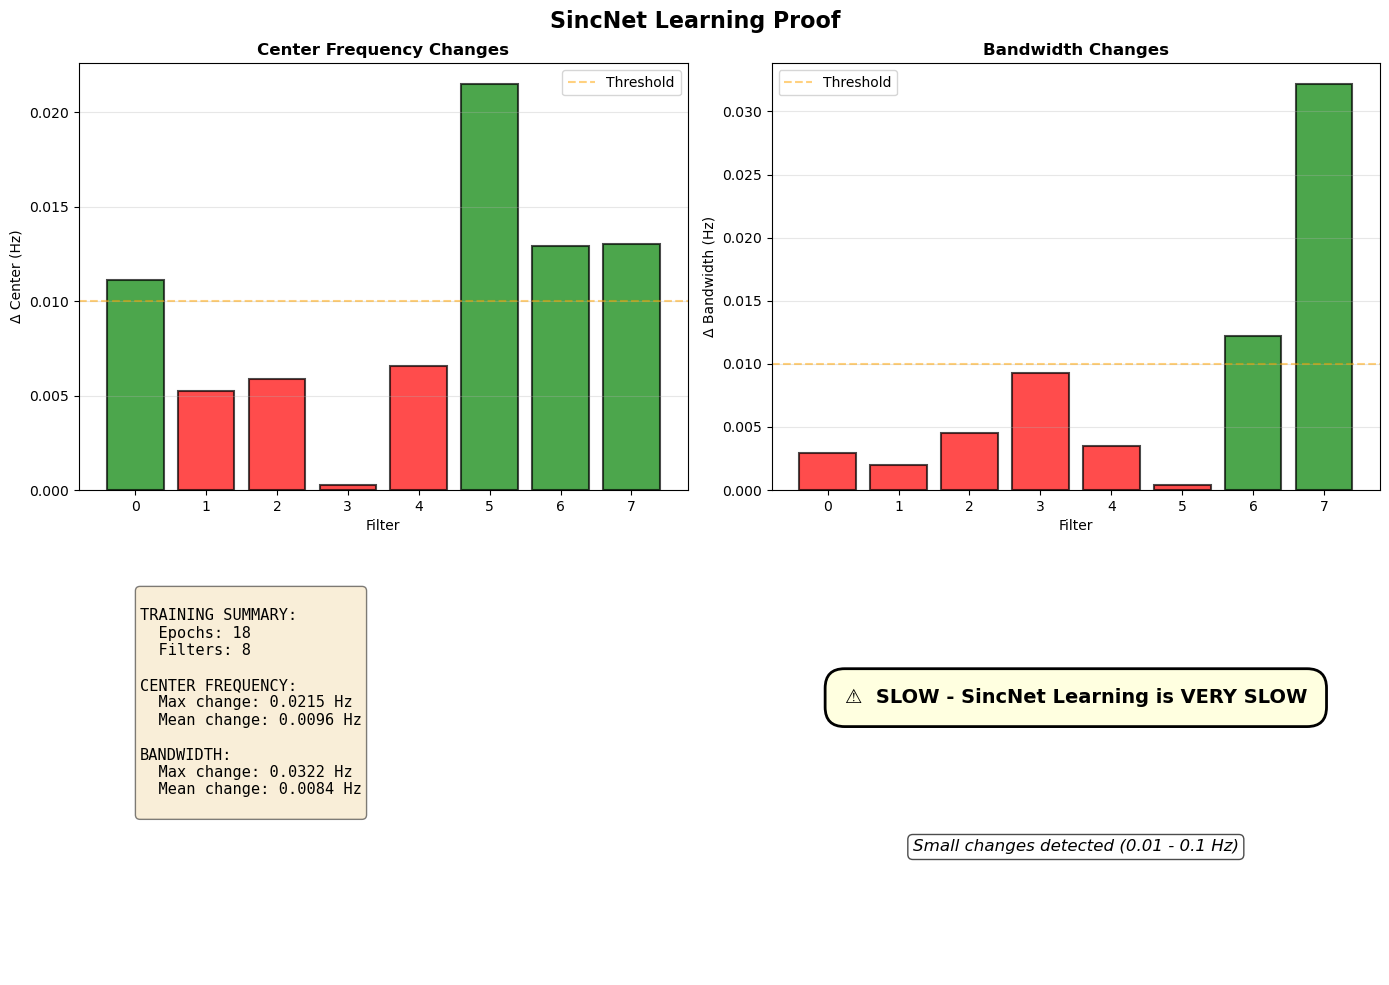

✓ Visualization saved to: sincnet_learning_proof.png


In [ ]:
11# === PROOF: Is SincNet Learning? ===
# Compare initial vs final frequency bands

print("\n" + "="*80)
print("SINCNET LEARNING PROOF")
print("="*80 + "\n")

n_filters = len(history['sinc_low_hz'][0])
n_epochs = len(history['sinc_epoch']) - 1

# Get initial (epoch 0) and final (last epoch) bands
center_init = history['sinc_center_hz'][0]
center_final = history['sinc_center_hz'][-1]
bw_init = history['sinc_bandwidth_hz'][0]
bw_final = history['sinc_bandwidth_hz'][-1]

# Calculate changes
center_changes = np.abs(center_final - center_init)
bw_changes = np.abs(bw_final - bw_init)

# Print per-filter results
print(f"Comparing Epoch 0 → Epoch {n_epochs}:\n")
for f in range(n_filters):
    print(f"Filter {f}:")
    print(f"  Center Freq: {center_init[f]:6.2f} Hz → {center_final[f]:6.2f} Hz | Δ = {center_changes[f]:8.4f} Hz")
    print(f"  Bandwidth:   {bw_init[f]:6.3f} Hz → {bw_final[f]:6.3f} Hz | Δ = {bw_changes[f]:8.4f} Hz\n")

# Summary statistics
max_center_change = np.max(center_changes)
max_bw_change = np.max(bw_changes)
mean_center_change = np.mean(center_changes)
mean_bw_change = np.mean(bw_changes)

print("="*80)
print(f"Max center frequency change:  {max_center_change:.4f} Hz")
print(f"Max bandwidth change:         {max_bw_change:.4f} Hz")
print(f"Mean center frequency change: {mean_center_change:.4f} Hz")
print(f"Mean bandwidth change:        {mean_bw_change:.4f} Hz")
print("="*80 + "\n")

# Verdict
if max_center_change > 0.1 or max_bw_change > 0.1:
    verdict = "✅ YES - SincNet IS LEARNING"
    reason = "Frequency bands changed significantly (> 0.1 Hz)"
    color = 'lightgreen'
elif max_center_change > 0.01 or max_bw_change > 0.01:
    verdict = "⚠️  SLOW - SincNet Learning is VERY SLOW"
    reason = "Small changes detected (0.01 - 0.1 Hz)"
    color = 'lightyellow'
else:
    verdict = "❌ NO - SincNet is NOT LEARNING"
    reason = "Frequency bands are FROZEN (changes < 0.01 Hz)"
    color = 'lightcoral'

print(verdict)
print(f"Reason: {reason}")
print("="*80 + "\n")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SincNet Learning Proof', fontsize=16, fontweight='bold')

# Plot 1: Center frequency changes
ax = axes[0, 0]
bar_colors = ['green' if x > 0.01 else 'red' for x in center_changes]
ax.bar(range(n_filters), center_changes, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_title('Center Frequency Changes', fontweight='bold')
ax.set_xlabel('Filter')
ax.set_ylabel('Δ Center (Hz)')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5, label='Threshold')
ax.legend()

# Plot 2: Bandwidth changes
ax = axes[0, 1]
bar_colors = ['green' if x > 0.01 else 'red' for x in bw_changes]
ax.bar(range(n_filters), bw_changes, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_title('Bandwidth Changes', fontweight='bold')
ax.set_xlabel('Filter')
ax.set_ylabel('Δ Bandwidth (Hz)')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.01, color='orange', linestyle='--', alpha=0.5, label='Threshold')
ax.legend()

# Plot 3: Summary text
ax = axes[1, 0]
ax.axis('off')
summary_text = f"""
TRAINING SUMMARY:
  Epochs: {n_epochs}
  Filters: {n_filters}

CENTER FREQUENCY:
  Max change: {max_center_change:.4f} Hz
  Mean change: {mean_center_change:.4f} Hz

BANDWIDTH:
  Max change: {max_bw_change:.4f} Hz
  Mean change: {mean_bw_change:.4f} Hz
"""
ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Verdict box
ax = axes[1, 1]
ax.axis('off')
ax.text(0.5, 0.65, verdict, transform=ax.transAxes, fontsize=14, fontweight='bold', 
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=1', facecolor=color, edgecolor='black', linewidth=2))
ax.text(0.5, 0.3, reason, transform=ax.transAxes, fontsize=12, ha='center', va='center',
        style='italic', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('sincnet_learning_proof.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: sincnet_learning_proof.png")


In [44]:
# Plot diagnostics collected during training

if len(history.get('diag_update_ratio', [])) == 0:
    print("No diagnostics collected. Run training first (with DIAG_EVERY=1).")
else:
    epochs_diag = np.arange(1, len(history['diag_grad_l2']) + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Gradient L2 norm per epoch
    ax = axes[0, 0]
    grad_l2 = np.array([v if v is not None else np.nan for v in history['diag_grad_l2']])
    ax.plot(epochs_diag, grad_l2, 'o-', linewidth=2, markersize=5, color='steelblue')
    ax.set_title(f'Gradient L2 Norm (Target: {TARGET_LAYER_NAME})', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('||grad||₂')
    ax.grid(True, alpha=0.3)
    # Warn if grad is consistently near zero
    valid_grads = grad_l2[~np.isnan(grad_l2)]
    if len(valid_grads) > 0 and np.mean(valid_grads) < 1e-6:
        ax.text(0.5, 0.95, '⚠️ Grad ~0: Check layer connection', 
                transform=ax.transAxes, ha='center', va='top', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Plot 2: Weight update ratio
    ax = axes[0, 1]
    ratio = np.array([v if v is not None else np.nan for v in history['diag_update_ratio']])
    ax.semilogy(epochs_diag, ratio, 's-', linewidth=2, markersize=5, color='orange')
    ax.axhline(y=1e-6, color='red', linestyle='--', label='Too small (<1e-6)', alpha=0.7)
    ax.axhline(y=1e-1, color='purple', linestyle='--', label='Unstable (>1e-1)', alpha=0.7)
    ax.set_title('Weight Update Ratio (||Δw|| / ||w||)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Update Ratio')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9)
    # Warnings
    valid_ratio = ratio[~np.isnan(ratio)]
    if len(valid_ratio) > 0:
        if np.mean(valid_ratio[-5:]) < 1e-6:
            ax.text(0.5, 0.05, '⚠️ Not learning (update too small)', 
                    transform=ax.transAxes, ha='center', va='bottom',
                    bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7), fontsize=9)
        elif np.mean(valid_ratio[-5:]) > 1e-1:
            ax.text(0.5, 0.05, '⚠️ Unstable (update too large)', 
                    transform=ax.transAxes, ha='center', va='bottom',
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.7), fontsize=9)
    
    # Plot 3: Dead filter percentage
    ax = axes[1, 0]
    dead_pct = np.array(history['diag_dead_pct'])
    ax.plot(epochs_diag, dead_pct, 'd-', linewidth=2, markersize=5, color='crimson')
    ax.set_title('Dead Filters %', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Dead Filters (%)')
    ax.set_ylim([-5, 105])
    ax.grid(True, alpha=0.3)
    if np.max(dead_pct) > 50:
        ax.text(0.5, 0.95, '⚠️ Many dead filters', 
                transform=ax.transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.7), fontsize=9)
    
    # Plot 4: Loss + Accuracy trends
    ax = axes[1, 1]
    ax_acc = ax.twinx()
    
    epochs_full = np.arange(1, len(history['train_loss']) + 1)
    l1 = ax.plot(epochs_full, history['train_loss'], 'o-', label='Train Loss', 
                 linewidth=2, markersize=4, color='blue')
    l2 = ax.plot(epochs_full, history['val_loss'], 's-', label='Val Loss', 
                 linewidth=2, markersize=4, color='navy')
    l3 = ax_acc.plot(epochs_full, history['train_acc'], '^-', label='Train Acc', 
                     linewidth=2, markersize=4, color='green', alpha=0.7)
    l4 = ax_acc.plot(epochs_full, history['val_acc'], 'v-', label='Val Acc', 
                     linewidth=2, markersize=4, color='darkgreen', alpha=0.7)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='blue')
    ax_acc.set_ylabel('Accuracy (%)', color='green')
    ax.set_title('Training Progress', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Combined legend
    lns = l1 + l2 + l3 + l4
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print warnings and summary
    print("\n" + "="*70)
    print("DIAGNOSTICS SUMMARY")
    print("="*70)
    
    valid_ratio = ratio[~np.isnan(ratio)]
    valid_grads = grad_l2[~np.isnan(grad_l2)]
    
    if len(valid_grads) > 0:
        print(f"\nGradient Stats (last 5 epochs):")
        print(f"  Mean ||grad||: {np.mean(valid_grads[-5:]):.2e}")
        print(f"  Min ||grad||:  {np.min(valid_grads[-5:]):.2e}")
    
    if len(valid_ratio) > 0:
        print(f"\nWeight Update Stats (last 5 epochs):")
        print(f"  Mean ratio: {np.mean(valid_ratio[-5:]):.2e}")
        print(f"  Max ratio:  {np.max(valid_ratio[-5:]):.2e}")
    
    print(f"\nDead Filter Stats:")
    print(f"  Max dead %: {np.max(dead_pct):.1f}%")
    print(f"  Mean dead %: {np.mean(dead_pct):.1f}%")
    
    # Check for loss NaN/Inf
    if np.any(np.isnan(history['train_loss'])) or np.any(np.isinf(history['train_loss'])):
        print("\n⚠️  WARNING: Training loss contains NaN/Inf!")
    
    # Check learning progress
    if len(history['train_loss']) >= 5:
        loss_improvement = (history['train_loss'][0] - history['train_loss'][-1]) / (history['train_loss'][0] + 1e-10)
        if loss_improvement < 0.01:
            print("\n⚠️  WARNING: Loss did not improve by >1% over full training.")
    
    print("="*70)


No diagnostics collected. Run training first (with DIAG_EVERY=1).


## 5b. Diagnostics Plots & Learning Quality

## 6. Training Visualization

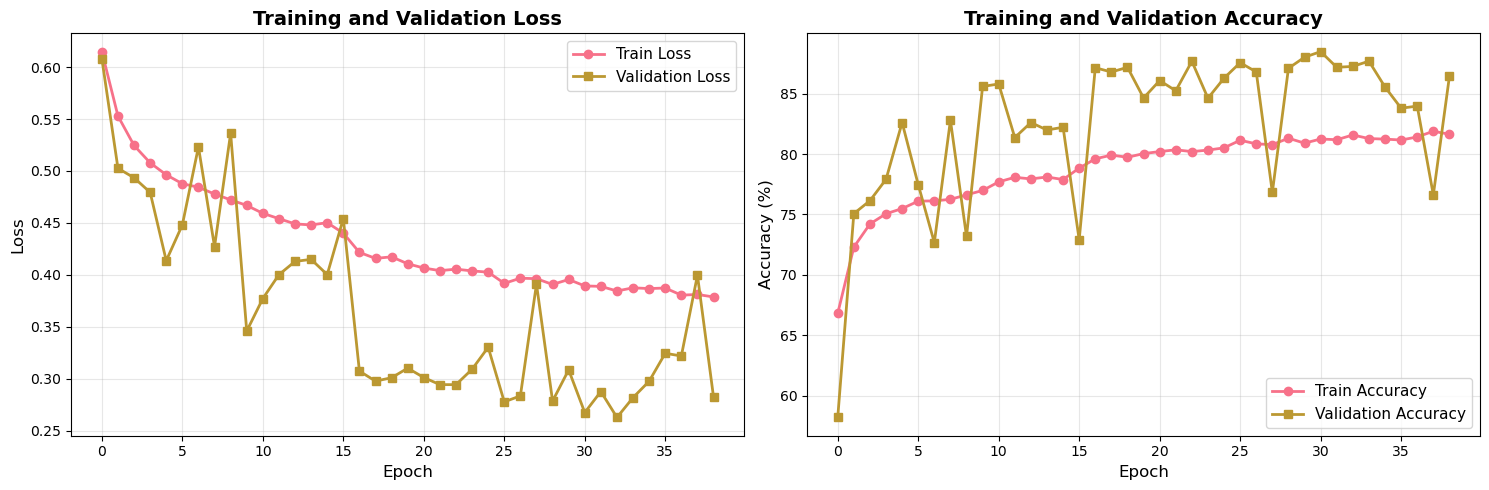


Training Summary:
  Final Train Loss: 0.3788
  Final Train Accuracy: 81.64%
  Final Val Loss: 0.2824
  Final Val Accuracy: 86.43%
  Best Val Accuracy: 88.48% (Epoch 31)


In [28]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTraining Summary:")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Final Val Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Best Val Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")

## 7. Load Best Model & Evaluate

In [29]:
# Load best model
checkpoint = torch.load('checkpoint_epoch/model_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 31
Validation accuracy: 88.48%


In [30]:
# Evaluate on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_probs = []
    
    with torch.no_grad():
        for data, labels, _ in test_loader:  # Unpack 3 values (data, labels, subject_id)
            data, labels = data.to(device), labels.to(device)
            
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_predictions), np.array(all_probs)

# Get predictions
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)

print("Test set evaluation completed.")
print(f"Total test samples: {len(y_true)}")

Test set evaluation completed.
Total test samples: 12570


## 8. Evaluation Metrics

## 8a. Per-Subject and Per-Class Evaluation

In [31]:
# Evaluate per-subject accuracy and per-class accuracy (Class 0 = normal, Class 1 = apnea)
# Re-run evaluation to also track subject ids

def evaluate_with_subjects(model, loader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_subjects = []
    all_probs_pos = []  # P(class=1)
    
    with torch.no_grad():
        for data, labels, subject_ids in loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_subjects.extend(np.array(subject_ids))
            all_probs_pos.extend(probs[:, 1].detach().cpu().numpy())
    
    return (np.array(all_labels), np.array(all_predictions), np.array(all_subjects), np.array(all_probs_pos))

# Use validation and test loaders
val_true_s, val_pred_s, val_subj, val_p1 = evaluate_with_subjects(model, val_loader, device)
test_true_s, test_pred_s, test_subj, test_p1 = evaluate_with_subjects(model, test_loader, device)

# Helper to compute per-subject accuracy
def per_subject_accuracy(y_true, y_pred, subjects):
    acc_by_subject = {}
    for subj in np.unique(subjects):
        mask = subjects == subj
        acc_by_subject[int(subj)] = (y_pred[mask] == y_true[mask]).mean()
    return acc_by_subject

val_acc_by_subj = per_subject_accuracy(val_true_s, val_pred_s, val_subj)
test_acc_by_subj = per_subject_accuracy(test_true_s, test_pred_s, test_subj)

print("Per-Subject Accuracy (Validation):")
for subj, acc in sorted(val_acc_by_subj.items()):
    print(f"  Subject {subj}: {acc*100:.2f}%")
print(f"Average Val Subject Accuracy: {np.mean(list(val_acc_by_subj.values()))*100:.2f}%")

print("\nPer-Subject Accuracy (Test):")
for subj, acc in sorted(test_acc_by_subj.items()):
    print(f"  Subject {subj}: {acc*100:.2f}%")
print(f"Average Test Subject Accuracy: {np.mean(list(test_acc_by_subj.values()))*100:.2f}%")

# Per-class accuracy (normal vs apnea)
def per_class_accuracy(y_true, y_pred):
    accs = {}
    for cls, name in [(0, 'Normal'), (1, 'Apnea')]:
        mask = y_true == cls
        accs[name] = (y_pred[mask] == cls).mean() if mask.sum() > 0 else np.nan
    return accs

val_class_acc = per_class_accuracy(val_true_s, val_pred_s)
test_class_acc = per_class_accuracy(test_true_s, test_pred_s)

print("\nPer-Class Accuracy (Validation):")
for k, v in val_class_acc.items():
    print(f"  {k}: {v*100:.2f}%" if not np.isnan(v) else f"  {k}: N/A")

print("\nPer-Class Accuracy (Test):")
for k, v in test_class_acc.items():
    print(f"  {k}: {v*100:.2f}%" if not np.isnan(v) else f"  {k}: N/A")

# ---- Threshold sweep to reduce 'always Apnea' behavior ----
# Find threshold on VAL that maximizes macro-F1, then report on TEST.
thresholds = np.linspace(0.05, 0.95, 19)
best = {'thr': 0.5, 'macro_f1': -1.0}
for thr in thresholds:
    val_pred_thr = (val_p1 >= thr).astype(int)
    mf1 = f1_score(val_true_s, val_pred_thr, average='macro')
    if mf1 > best['macro_f1']:
        best = {'thr': float(thr), 'macro_f1': float(mf1)}

thr = best['thr']
print(f"\nBest threshold on VAL (by macro-F1): {thr:.2f} (macro-F1={best['macro_f1']:.4f})")

test_pred_thr = (test_p1 >= thr).astype(int)
print("Thresholded metrics on TEST:")
print("-" * 70)
print(f"Accuracy:     {accuracy_score(test_true_s, test_pred_thr)*100:.2f}%")
print(f"Balanced Acc: {recall_score(test_true_s, test_pred_thr, average='macro')*100:.2f}%")
print(f"Macro F1:     {f1_score(test_true_s, test_pred_thr, average='macro'):.4f}")
print("\nClassification report (thresholded):")
print(classification_report(test_true_s, test_pred_thr, target_names=['Class 0', 'Class 1'], digits=4))

Per-Subject Accuracy (Validation):
  Subject 3: 93.46%
  Subject 11: 85.32%
  Subject 23: 94.22%
  Subject 24: 78.35%
  Subject 36: 84.97%
  Subject 41: 88.47%
  Subject 44: 95.05%
Average Val Subject Accuracy: 88.55%

Per-Subject Accuracy (Test):
  Subject 8: 68.93%
  Subject 15: 72.74%
  Subject 19: 88.76%
  Subject 21: 72.36%
  Subject 29: 78.11%
  Subject 39: 82.52%
  Subject 43: 79.69%
  Subject 50: 68.82%
Average Test Subject Accuracy: 76.49%

Per-Class Accuracy (Validation):
  Normal: 86.33%
  Apnea: 90.55%

Per-Class Accuracy (Test):
  Normal: 65.10%
  Apnea: 88.53%

Best threshold on VAL (by macro-F1): 0.50 (macro-F1=0.8846)
Thresholded metrics on TEST:
----------------------------------------------------------------------
Accuracy:     76.47%
Balanced Acc: 76.81%
Macro F1:     0.7625

Classification report (thresholded):
              precision    recall  f1-score   support

     Class 0     0.8575    0.6510    0.7401      6469
     Class 1     0.7052    0.8853    0.7850     

In [32]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Extra metrics that matter when one class collapses
balanced_acc = recall_score(y_true, y_pred, average='macro')  # macro-recall == balanced accuracy for binary
macro_f1 = f1_score(y_true, y_pred, average='macro')

print("=" * 70)
print("TEST SET PERFORMANCE METRICS")
print("=" * 70)
print(f"Accuracy:        {accuracy*100:.2f}%")
print(f"Balanced Acc:    {balanced_acc*100:.2f}%")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Precision(w):    {precision:.4f}")
print(f"Recall(w):       {recall:.4f}")
print(f"F1-Score(w):     {f1:.4f}")
print("=" * 70)

# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT:")
print("-" * 70)
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1'], digits=4))

# Per-class metrics
print("\nPER-CLASS METRICS:")
print("-" * 70)
for i in range(2):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        print(f"Class {i} - Samples: {mask.sum():4d} | Accuracy: {class_acc*100:.2f}%")

TEST SET PERFORMANCE METRICS
Accuracy:        76.47%
Balanced Acc:    76.81%
Macro F1:        0.7625
Precision(w):    0.7836
Recall(w):       0.7647
F1-Score(w):     0.7619

DETAILED CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Class 0     0.8575    0.6510    0.7401      6469
     Class 1     0.7052    0.8853    0.7850      6101

    accuracy                         0.7647     12570
   macro avg     0.7813    0.7681    0.7625     12570
weighted avg     0.7836    0.7647    0.7619     12570


PER-CLASS METRICS:
----------------------------------------------------------------------
Class 0 - Samples: 6469 | Accuracy: 65.10%
Class 1 - Samples: 6101 | Accuracy: 88.53%


## 9. Confusion Matrix

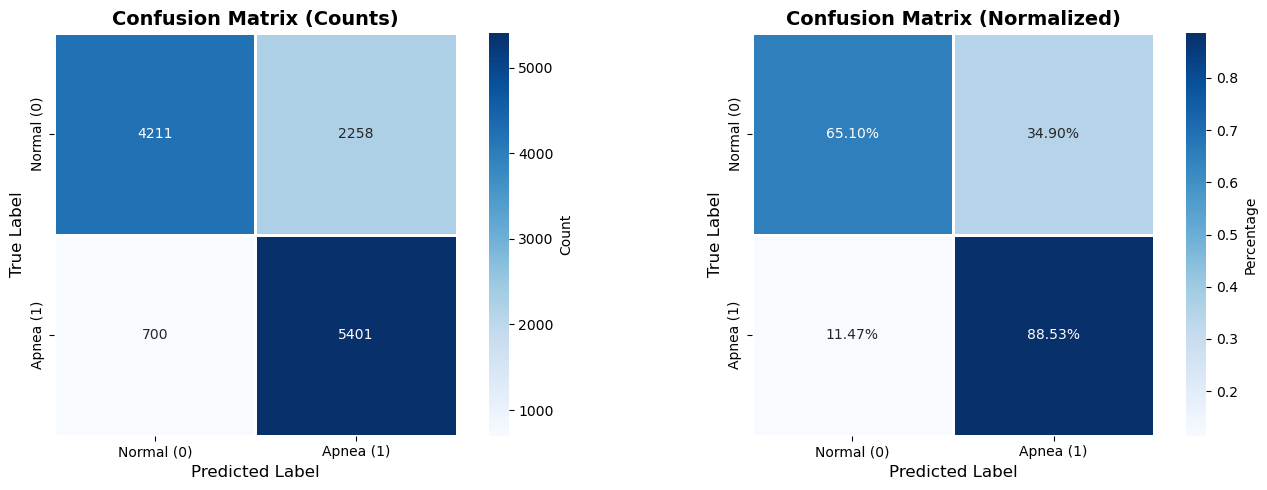


Confusion Matrix Analysis:
----------------------------------------------------------------------
True Negatives (TN):  4211  |  False Positives (FP): 2258
False Negatives (FN):  700  |  True Positives (TP):  5401

Sensitivity (Recall): 0.8853
Specificity:          0.6510


In [49]:
# Confusion matrix (Normal=0, Apnea=1) with Normal on the first row/col
class_names = ['Normal (0)', 'Apnea (1)']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, square=True, linewidths=1)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(class_names)
axes[0].set_yticklabels(class_names)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1], 
            cbar_kws={'label': 'Percentage'}, square=True, linewidths=1)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(class_names)
axes[1].set_yticklabels(class_names)

plt.tight_layout()
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix Analysis:")
print("-" * 70)
print(f"True Negatives (TN):  {cm[0, 0]:4d}  |  False Positives (FP): {cm[0, 1]:4d}")
print(f"False Negatives (FN): {cm[1, 0]:4d}  |  True Positives (TP):  {cm[1, 1]:4d}")

if cm.shape[0] == 2:  # Binary classification
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\nSensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity:          {specificity:.4f}")

## 10. SincNet Filter Visualization

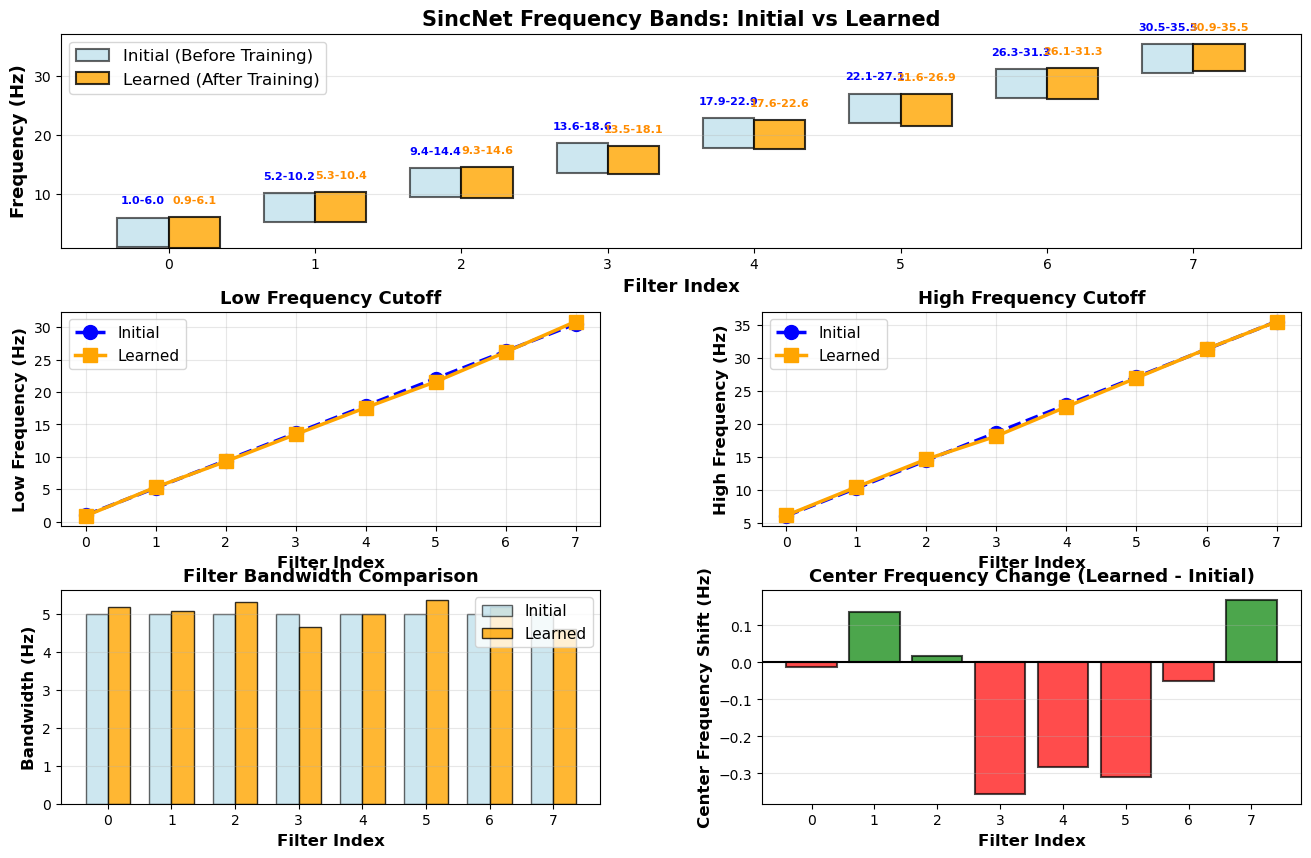


Learned vs Initial Frequency Bands:
Filter   Initial Low   Initial High  Learned Low   Learned High  Shift     
------------------------------------------------------------------------------------------
Filter 0          1.00 Hz         6.00 Hz         0.89 Hz          6.08 Hz    -0.01 Hz
Filter 1          5.21 Hz        10.21 Hz         5.31 Hz         10.39 Hz    +0.14 Hz
Filter 2          9.43 Hz        14.43 Hz         9.29 Hz         14.61 Hz    +0.02 Hz
Filter 3         13.64 Hz        18.64 Hz        13.46 Hz         18.12 Hz    -0.36 Hz
Filter 4         17.86 Hz        22.86 Hz        17.58 Hz         22.57 Hz    -0.28 Hz
Filter 5         22.07 Hz        27.07 Hz        21.58 Hz         26.94 Hz    -0.31 Hz
Filter 6         26.29 Hz        31.29 Hz        26.15 Hz         31.33 Hz    -0.05 Hz
Filter 7         30.50 Hz        35.50 Hz        30.87 Hz         35.47 Hz    +0.17 Hz

Learning Summary:
---------------------------------------------------------------------------------

In [34]:
# Visualize learned frequency bands and compare with initial
sinc_layer = model.sinc

low_hz = sinc_layer.min_freq + torch.abs(sinc_layer.low_hz_).detach().cpu().numpy()
high_hz = low_hz + torch.abs(sinc_layer.band_hz_).detach().cpu().numpy()
high_hz = np.clip(high_hz, sinc_layer.min_freq, sinc_layer.max_freq)

# Create comprehensive visualization comparing initial vs learned
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Frequency bands comparison (Initial vs Learned)
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(low_hz))
width = 0.35

# Plot initial frequencies
ax1.bar(x - width/2, high_hz_init - low_hz_init, width, bottom=low_hz_init, 
        label='Initial (Before Training)', alpha=0.6, edgecolor='black', linewidth=1.5, color='lightblue')
# Plot learned frequencies
ax1.bar(x + width/2, high_hz - low_hz, width, bottom=low_hz, 
        label='Learned (After Training)', alpha=0.8, edgecolor='black', linewidth=1.5, color='orange')

ax1.set_xlabel('Filter Index', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency (Hz)', fontsize=13, fontweight='bold')
ax1.set_title('SincNet Frequency Bands: Initial vs Learned', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(x)

# Add annotations
for i in range(len(low_hz)):
    # Initial
    ax1.text(i - width/2, high_hz_init[i] + 2, f'{low_hz_init[i]:.1f}-{high_hz_init[i]:.1f}', 
            ha='center', va='bottom', fontsize=8, color='blue', fontweight='bold')
    # Learned
    ax1.text(i + width/2, high_hz[i] + 2, f'{low_hz[i]:.1f}-{high_hz[i]:.1f}', 
            ha='center', va='bottom', fontsize=8, color='darkorange', fontweight='bold')

# 2. Low frequency comparison
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, low_hz_init, marker='o', markersize=10, label='Initial', linewidth=2.5, color='blue', linestyle='--')
ax2.plot(x, low_hz, marker='s', markersize=10, label='Learned', linewidth=2.5, color='orange')
ax2.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Low Frequency (Hz)', fontsize=12, fontweight='bold')
ax2.set_title('Low Frequency Cutoff', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x)

# 3. High frequency comparison
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(x, high_hz_init, marker='o', markersize=10, label='Initial', linewidth=2.5, color='blue', linestyle='--')
ax3.plot(x, high_hz, marker='s', markersize=10, label='Learned', linewidth=2.5, color='orange')
ax3.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax3.set_ylabel('High Frequency (Hz)', fontsize=12, fontweight='bold')
ax3.set_title('High Frequency Cutoff', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(x)

# 4. Bandwidth comparison
ax4 = fig.add_subplot(gs[2, 0])
bandwidth_init = high_hz_init - low_hz_init
bandwidth_learned = high_hz - low_hz
x_pos = np.arange(len(bandwidth_learned))
bars1 = ax4.bar(x_pos - width/2, bandwidth_init, width, label='Initial', alpha=0.6, color='lightblue', edgecolor='black')
bars2 = ax4.bar(x_pos + width/2, bandwidth_learned, width, label='Learned', alpha=0.8, color='orange', edgecolor='black')
ax4.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax4.set_ylabel('Bandwidth (Hz)', fontsize=12, fontweight='bold')
ax4.set_title('Filter Bandwidth Comparison', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticks(x_pos)

# 5. Center frequency shift
ax5 = fig.add_subplot(gs[2, 1])
center_hz_init = (low_hz_init + high_hz_init) / 2
center_hz_learned = (low_hz + high_hz) / 2
center_shift = center_hz_learned - center_hz_init
colors = ['green' if s >= 0 else 'red' for s in center_shift]
bars = ax5.bar(x, center_shift, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax5.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax5.set_ylabel('Center Frequency Shift (Hz)', fontsize=12, fontweight='bold')
ax5.set_title('Center Frequency Change (Learned - Initial)', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_xticks(x)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nLearned vs Initial Frequency Bands:")
print("=" * 90)
print(f"{'Filter':<8} {'Initial Low':<13} {'Initial High':<13} {'Learned Low':<13} {'Learned High':<13} {'Shift':<10}")
print("-" * 90)
for i in range(len(low_hz)):
    low_shift = low_hz[i] - low_hz_init[i]
    high_shift = high_hz[i] - high_hz_init[i]
    print(f"Filter {i:<3} {low_hz_init[i]:>11.2f} Hz {high_hz_init[i]:>12.2f} Hz {low_hz[i]:>12.2f} Hz {high_hz[i]:>13.2f} Hz {center_shift[i]:>+8.2f} Hz")
print("=" * 90)

print("\nLearning Summary:")
print("-" * 90)
print(f"Average center frequency shift: {np.mean(np.abs(center_shift)):.2f} Hz")
print(f"Max center frequency shift: {np.max(np.abs(center_shift)):.2f} Hz")
print(f"Average bandwidth change: {np.mean(bandwidth_learned - bandwidth_init):.2f} Hz")
print("=" * 90)

## 11. Summary & Save Results

In [35]:
# Save learned frequency bands to CSV
frequency_bands_df = pd.DataFrame({
    'Filter': [f'Filter_{i}' for i in range(len(low_hz))],
    'Low_Hz': low_hz,
    'High_Hz': high_hz,
    'Bandwidth_Hz': high_hz - low_hz
})
frequency_bands_df.to_csv('learned_frequency_bands.csv', index=False)
print("Saved learned frequency bands to 'learned_frequency_bands.csv'")

# Save training history to CSV
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, len(history_df) + 1)
history_df = history_df[['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc']]
history_df.to_csv('training_history.csv', index=False)
print("Saved training history to 'training_history.csv'")

# Create comprehensive results summary
results_summary = {
    'Model': 'SincNet-ECG',
    'Total_Parameters': sum(p.numel() for p in model.parameters()),
    'SincNet_Filters': len(low_hz),
    'Best_Epoch': best_epoch,
    'Best_Val_Acc': best_val_acc,
    'Test_Accuracy': accuracy * 100,
    'Test_Precision': precision,
    'Test_Recall': recall,
    'Test_F1': f1,
    'Train_Samples': len(train_idx),
    'Val_Samples': len(val_idx),
    'Test_Samples': len(test_idx)
}

# Save results summary
results_df = pd.DataFrame([results_summary])
results_df.to_csv('model_results_summary.csv', index=False)
print("Saved model results summary to 'model_results_summary.csv'")

# Print final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Model: SincNet-ECG with {len(low_hz)} filters")
print(f"Total Parameters: {results_summary['Total_Parameters']:,}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
print(f"Test Set Performance:")
print(f"  - Accuracy:  {accuracy*100:.2f}%")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print("=" * 70)
print("\n✅ Training and evaluation complete!")

Saved learned frequency bands to 'learned_frequency_bands.csv'
Saved training history to 'training_history.csv'
Saved model results summary to 'model_results_summary.csv'

FINAL SUMMARY
Model: SincNet-ECG with 8 filters
Total Parameters: 13,970
Best Validation Accuracy: 88.48% (Epoch 31)
Test Set Performance:
  - Accuracy:  76.47%
  - Precision: 0.7836
  - Recall:    0.7647
  - F1-Score:  0.7619

✅ Training and evaluation complete!
